
# Bank Customer Churn Prediction
Bu projede bir bankaya ait müşteri verileri kullanılarak müşterilerin bankayı bırakma (churn) davranışı analiz edilmektedir.

Veri setinde, müşterilere ait kredi skoru, ülke, cinsiyet, yaş, banka ile çalışma süresi, hesap bakiyesi, ürün sayısı sahipliği, kredi kartı sahipliği, müşteri aktiflik durumu ve tahmini maaş gibi değişkenler yer almaktadır.

Bu çalışmanın temel amacı:

- Müşteri kaybına neden olabilecek faktörleri incelemek
- Bir müşterinin bankayı bırakma ihtimalini tahmin eden bir makine öğrenmesi modeli kurmak
- Churn olasılığına göre müşterileri risk seviyelerine ayırmaktır


# 1. Kütüphaneler ve Veri Yükleme

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, recall_score, roc_auc_score, precision_score

sns.set_style("whitegrid")

# proje renk paleti
main_blue = sns.color_palette("Blues", 8)[5]

In [53]:
df = pd.read_csv("Bank Customer Churn Prediction.csv")


# 2. Veri Setinin Yapısı ve Veri Kalite Kontrolü

In [5]:
print(f"Veri seti boyutu: {df.shape[0]} satır, {df.shape[1]} sütun")
df.head()

Veri seti boyutu: 10000 satır, 12 sütun


,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [7]:
df.isnull().sum()


,0
customer_id,0
credit_score,0
country,0
gender,0
age,0
tenure,0
balance,0
products_number,0
credit_card,0
active_member,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
print("Toplam müşteri sayısı:", len(df))
print("Benzersiz customer_id sayısı:", df["customer_id"].nunique())
print("customer_id primary key mi?:", df["customer_id"].nunique() == len(df))

Toplam müşteri sayısı: 10000
Benzersiz customer_id sayısı: 10000
customer_id primary key mi?: True


Veri setinde eksik değer bulunmamaktadır ve tekrar eden kayıt yoktur. Ayrıca customer_id değişkeninin her müşteri için benzersiz olduğu görülmektedir. Bu nedenle veri seti analiz ve modelleme için temiz ve uygun durumdadır.

# 3. Verinin İstatistiksel Özeti

In [10]:
#Temel İstatistikler
df.describe()

,customer_id,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
count,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [11]:
df["country"].value_counts()
df["gender"].value_counts()

,count
gender,
Male,5457
Female,4543


In [12]:
df.describe(include="object")

,country,gender
count,10000,10000
unique,3,2
top,France,Male
freq,5014,5457


**İstatistiksel Sonuçların Değerlendirmesi:**


Veri setindeki sayısal ve kategorik değişkenlerin temel istatistikleri incelenmiştir.

**Credit score:**
Müşterilerin ortalama kredi skorunun yaklaşık 650 olduğu görülmektedir. Minimum değer 350, maksimum değer ise 850’dir. Bu durum veri setinde düşük riskli ve yüksek riskli müşteri gruplarının birlikte yer aldığını göstermektedir.

**Yaş:**
Müşterilerin ortalama yaşının yaklaşık 39 olduğu görülmektedir. Minimum yaş 18, maksimum yaş ise 92’dir. Bu durum veri setinin ağırlıklı olarak orta yaş müşteri grubunu temsil ettiğini göstermektedir.

**Tenure:**
Değişkenin istatistiksel değerlerine bakıldığında, veri setinde hem yeni hem de uzun süredir müşteri olan kişilerin bulunduğu görülmektedir. Tenure değerinin 0 ile 10 yıl arasında değiştiği anlaşılmaktadır.

**Balance:**
Minimum değerin 0 olduğu görülmektedir. Ayrıca ilk çeyreklik değerin (25%) de 0 olması, veri setinde önemli sayıda müşterinin hesap bakiyesinin sıfır olduğunu göstermektedir. Bununla birlikte maksimum bakiye değerinin oldukça yüksek olması, müşteri finansal profillerinin çeşitlilik gösterdiğini düşündürmektedir.

**Products number:**
Müşterilerin kullandığı ürün sayısının ortalama olarak 1–2 aralığında olduğu görülmektedir. Maksimum değerin 4 olması, veri setinde bankanın birden fazla ürününü kullanan müşteri grubunun da bulunduğunu göstermektedir. Veri setindeki müşterilerin ağırlıklı ürün sahiplik değeri 1’dir.

**Credit card:**
Ortalama değerin yaklaşık 0,70 olması, müşterilerin önemli bir kısmının kredi kartına sahip olduğunu göstermektedir.

**Active member:**
Ortalama değerin yaklaşık 0,51 olması, aktif ve pasif müşteri sayısının veri setinde birbirine yakın olduğunu göstermektedir.

**Estimated salary:**
Değişken geniş bir aralığa sahiptir. Minimum değer yaklaşık 11, maksimum değer ise yaklaşık 200.000 civarındadır. Bu da veri setinde farklı gelir seviyelerine sahip müşterilerin bulunduğunu göstermektedir.

**Churn:**
Ortalama değerin yaklaşık 0,20 olması, veri setinde müşterilerin yaklaşık %20’sinin bankadan ayrıldığını göstermektedir. Bu durum veri setinin kısmen dengesiz bir yapıya sahip olabileceğine işaret etmektedir.

**Country:**
Veri setinde müşterilerin üç farklı ülkeden (France, Germany, Spain) geldiği görülmektedir. En fazla müşteri Fransa’ya aittir. Bu durum veri setinde ülke dağılımının dengeli olmadığını ve analizlerde ülke bazlı yorum yapılırken bu durumun dikkate alınması gerektiğini göstermektedir.

**Gender:**
Müşterilerin yaklaşık %55’inin erkek, %45’inin kadın olduğu görülmektedir. Bu durum veri setinde cinsiyet dağılımının birbirine yakın olmakla birlikte erkek müşterilerin sayısının biraz daha fazla olduğunu göstermektedir.



# 4. Değişken Dağılımları

Değişkenler sayısal ve kategorik olarak sınıflandırılmıştır.

NOT:  **products_number** değişkeni sayısal değerlerden oluşmaktadır. Fakat sadece 1 ile 4 arasında az sayıda farklı değer içerdiği için dağılım analizlerinde kategorik değişken olarak incelenmiştir.

In [13]:
categorical_cols = [
    "country",
    "gender",
    "credit_card",
    "active_member",
    "products_number",
    "churn"
]

numerical_cols = [
    "credit_score",
    "age",
    "tenure",
    "balance",
    "estimated_salary"
]
print(f"Kategorik değişkenler: {categorical_cols}")
print(f"Sayısal değişkenler: {numerical_cols}")

Kategorik değişkenler: ['country', 'gender', 'credit_card', 'active_member', 'products_number', 'churn']
Sayısal değişkenler: ['credit_score', 'age', 'tenure', 'balance', 'estimated_salary']


## 4.1 Sayısal Değişkenlerin Dağılımları (Histogram Grafiği)

Bu bölümde sayısal değişkenlerin veri seti içindeki dağılımları incelenmiştir. Amaç, bu özelliklerinin hangi aralıklarda yoğunlaştığını görmek ve veri setinin genel yapısını daha iyi anlamaktır.

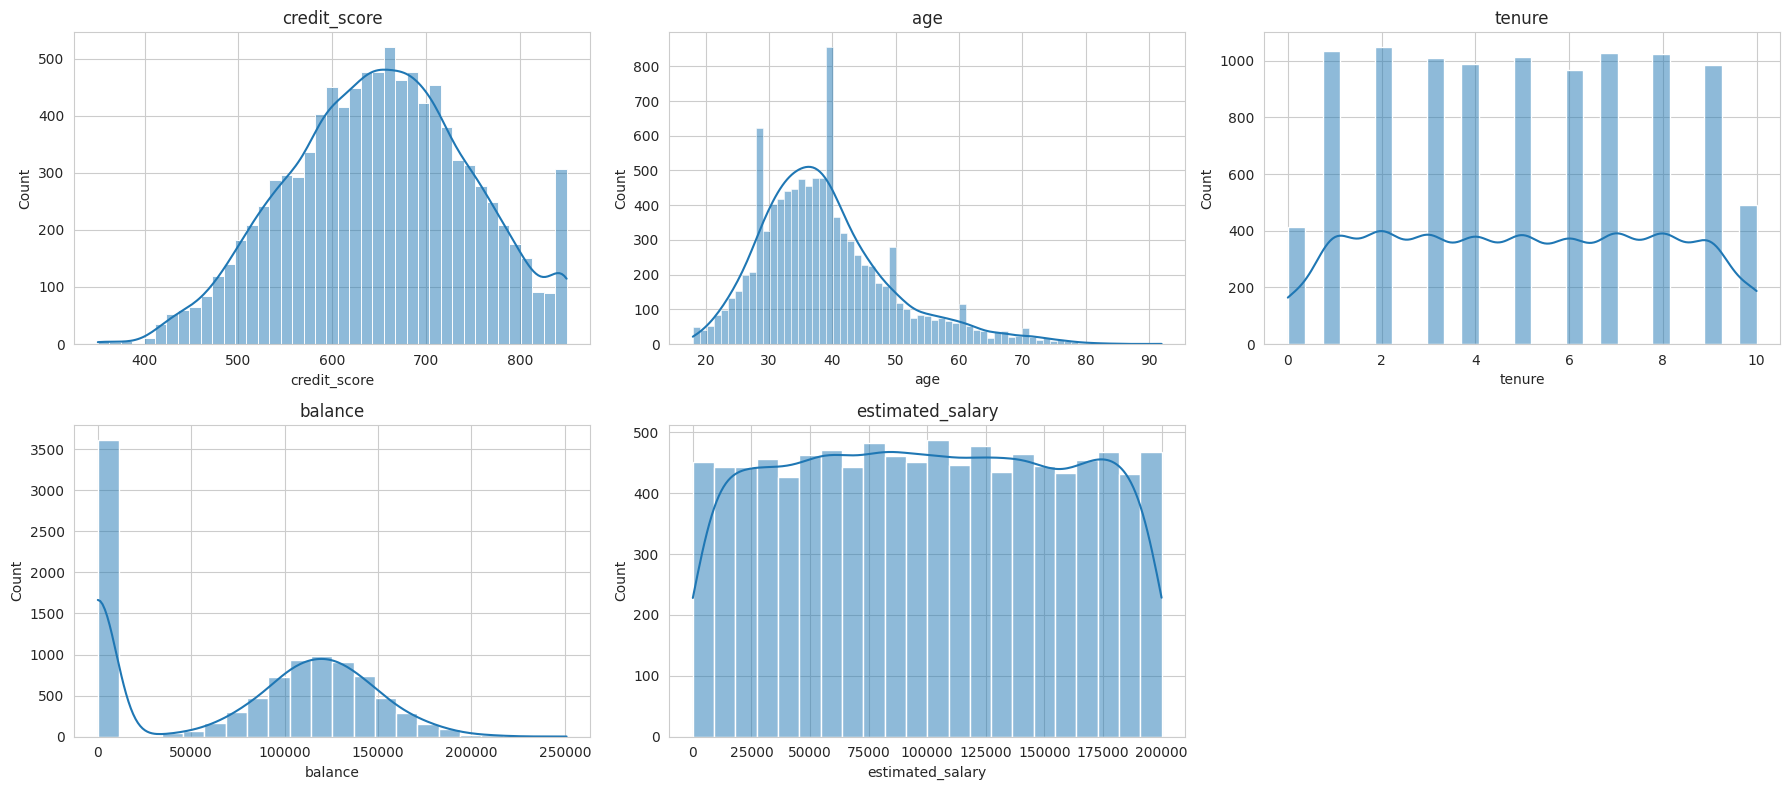

In [14]:
numerical_cols = [
    "credit_score",
    "age",
    "tenure",
    "balance",
    "estimated_salary"
]

plt.figure(figsize=(18,8))

for i, col in enumerate(numerical_cols):
    plt.subplot(2,3,i+1)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

**Histogram grafikleri** incelendiğinde, bazı değişkenlerin belirli aralıklarda yoğunlaştığı, bazılarının ise daha geniş bir dağılım gösterdiği görülmektedir. Bu durum veri setinin homojen olmadığını ve müşteri profillerinin farklı özellikler taşıdığını göstermektedir. Bu gözlemler sonraki analizlerde churn davranışını yorumlamak için önemli bir temel oluşturmaktadır

## 4.2 Kategorik Değişken Dağılımları (Bar Chart)

Bu bölümde kategorik değişkenlerin dağılımları incelenmiştir. Böylece veri setindeki müşteri yapısı genel olarak görülmekte ve değişkenlerin hangi kategorilerde yoğunlaştığı anlaşılmaktadır.

**NOT:** **products_number** sayısal bir değişkendir. Veri setinde bu değişken 1- 4 ürün gibi dar bir aralıkta olduğu için grafiksel olarak yapısının bar grafikte daha net görülebileceği düşünülerek kategorik değişkenler altında grafikleştirilmiştir. Çalışma boyunca sayısal değişken olarak incelenmiştir.

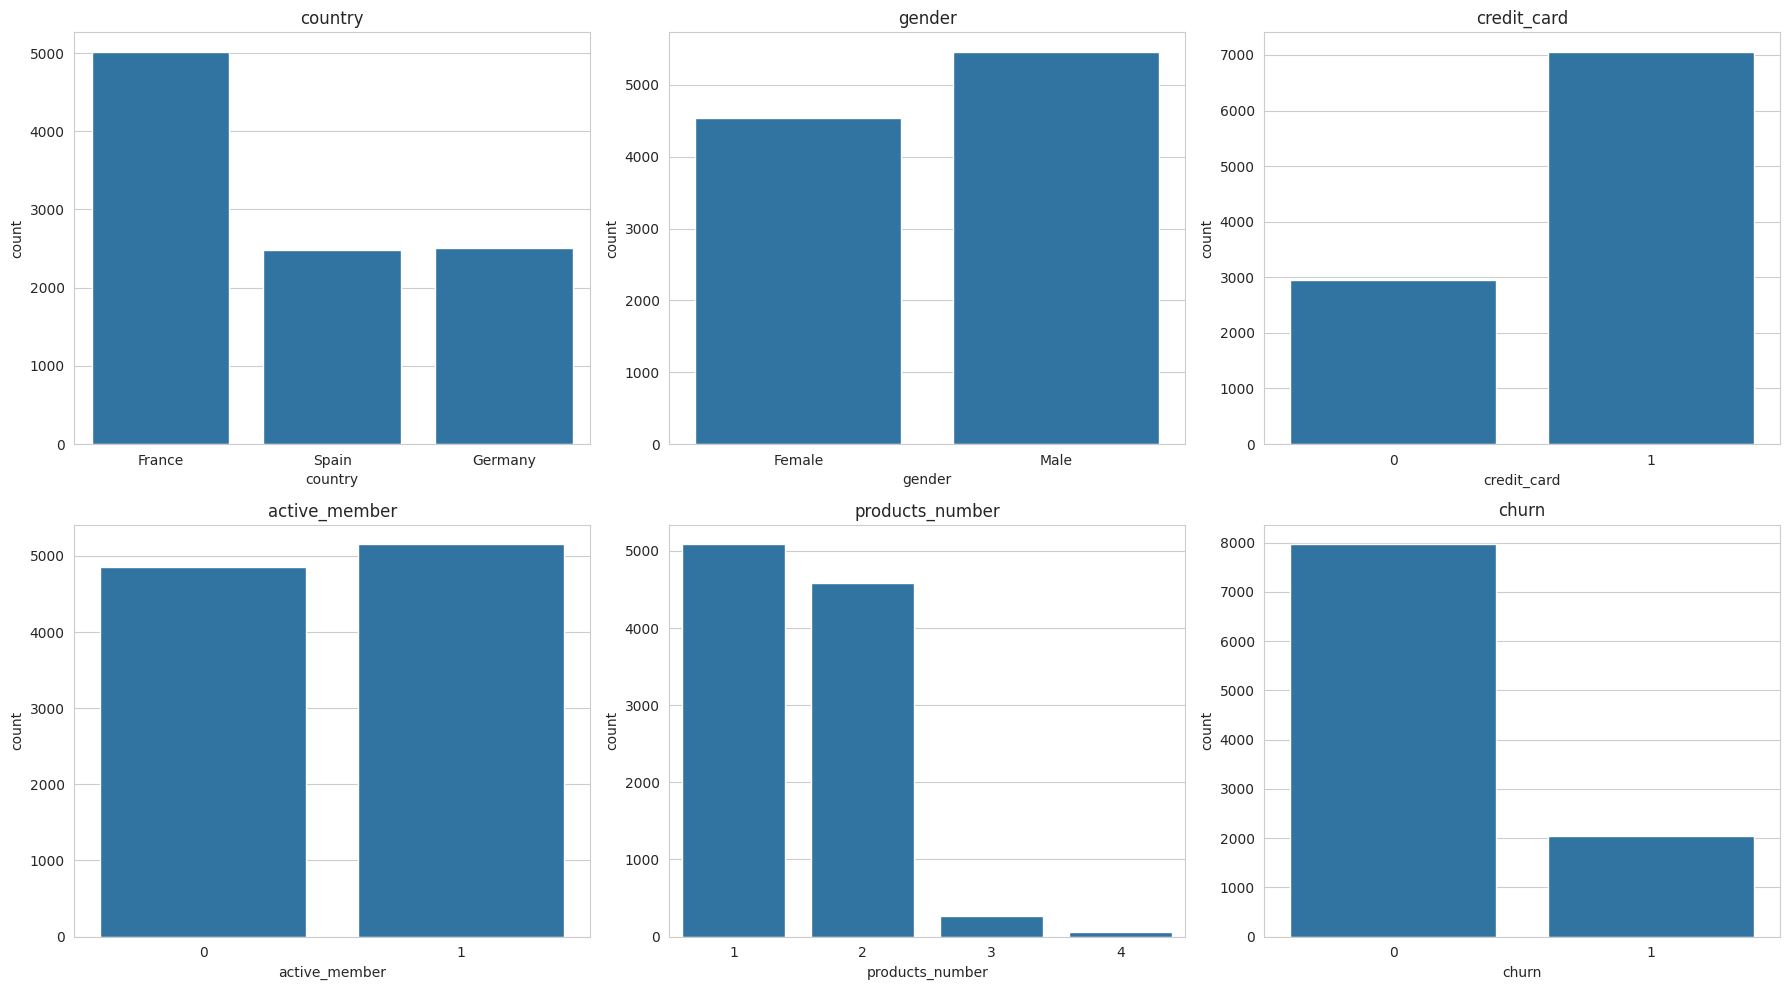

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

categorical_cols = [
    "country",
    "gender",
    "credit_card",
    "active_member",
    "products_number",
    "churn"
]

plt.figure(figsize=(18,10))

for i, col in enumerate(categorical_cols):
    plt.subplot(2,3,i+1)
    sns.countplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

**Bar grafikler** incelendiğinde müşterilerin belirli kategorilerde yoğunlaştığı görülmektedir. Bu durum veri setinde bazı müşteri gruplarının diğerlerine göre daha baskın olduğunu göstermektedir. Elde edilen bu genel yapı, churn analizinde hangi müşteri segmentlerinin daha dikkatle incelenmesi gerektiği konusunda yol gösterici olacaktır. Churn değişkeninin genel durumu ise bir sonraki bölümde Overall KPI kapsamında detaylı olarak ele alınacaktır.

Bu çalışmada modelin tahmin etmeye çalışacağı hedef değişken churn değişkenidir. Churn değeri 1 olan müşteriler bankadan ayrılmış, 0 olan müşteriler ise bankada kalmaya devam etmiştir. Veri setindeki diğer değişkenler ise müşterilerin demografik, finansal ve davranışsal özelliklerini temsil etmektedir. Bu değişkenler model için potansiyel özellik (feature) olarak değerlendirilecektir. Hangi değişkenlerin modele dahil edileceğine dair EDA aşamasında yapılan analizler sonucunda bir fikir sahibi olunacaktır.


# 5. Overall Churn (Makro Seviye)



## 5.1 Genel Churn İncelemesi

Bu bölümde veri setindeki müşterilerin genel churn durumu ele alınmıştır. Toplam müşteri sayısı, ayrılan müşteri sayısı ve genel churn oranı hesaplanarak veri setinin makro seviyedeki müşteri kaybı incelenmektedir. Ardından churn durumunun müşteri dağılımı grafik ile görselleştirilmektedir.

In [16]:
total_customers = df.shape[0]
churn_customers = df['churn'].sum()
churn_rate = churn_customers / total_customers

print(f'Toplam Musteri     : {total_customers:,}')
print(f'Ayrilan Musteri    : {churn_customers:,}')
print(f'Kalan Musteri      : {total_customers - churn_customers:,}')
print(f'Genel Churn Orani  : %{churn_rate*100:.1f}')

Toplam Musteri     : 10,000
Ayrilan Musteri    : 2,037
Kalan Musteri      : 7,963
Genel Churn Orani  : %20.4


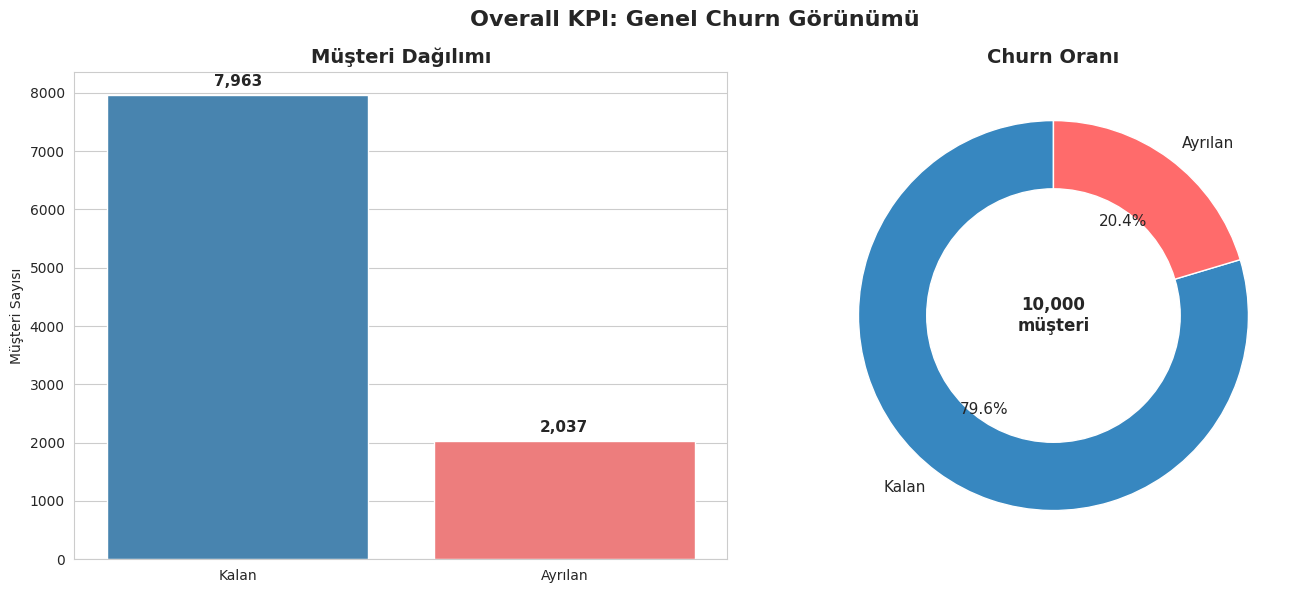

In [17]:
# Overall KPI sayısal hesaplama
total_customers = len(df)
churn_counts = df['churn'].value_counts()

churned = churn_counts[1]
retained = churn_counts[0]

churn_rate = churned / total_customers * 100
retention_rate = retained / total_customers * 100


# Grafik için değerler
labels = ['Kalan', 'Ayrılan']
values = [retained, churned]
colors = [main_blue, '#ff6b6b']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sol grafik: Bar chart
sns.barplot(x=labels, y=values, hue=labels, ax=axes[0], palette=colors, legend=False)
axes[0].set_title("Müşteri Dağılımı", fontsize=14, fontweight='bold')
axes[0].set_xlabel("")
axes[0].set_ylabel("Müşteri Sayısı")

for i, v in enumerate(values):
    axes[0].text(i, v + 150, f"{v:,}", ha='center', fontsize=11, fontweight='bold')

# Sağ grafik: Donut chart
wedges, texts, autotexts = axes[1].pie(
    values,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 11}
)

centre_circle = plt.Circle((0, 0), 0.65, fc='white')
axes[1].add_artist(centre_circle)

axes[1].text(0, 0, f"{total_customers:,}\nmüşteri", ha='center', va='center',
             fontsize=12, fontweight='bold')

axes[1].set_title("Churn Oranı", fontsize=14, fontweight='bold')

plt.suptitle("Overall KPI: Genel Churn Görünümü", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Veri setinde toplam 10.000 müşteri bulunmaktadır. Bunların 2.037’si bankadan ayrılmış, 7.963’ü ise müşteri olarak kalmaya devam etmektedir. Buna göre genel churn oranı yaklaşık %20,4’tür. Bu sonuç veri setinde yaklaşık her 5 müşteriden 1’inin bankadan ayrıldığını göstermektedir.

## 5.2 Tüm Değişkenlere Göre Churn Oranlarının Genel İncelenmesi

Bu bölümde churn oranı tüm değişkenler bazında genel olarak incelenmiştir.
Amaç, churn davranışının hangi müşteri gruplarında daha yoğunlaştığını ilk aşamada genel bir bakış açısıyla görebilmektir.

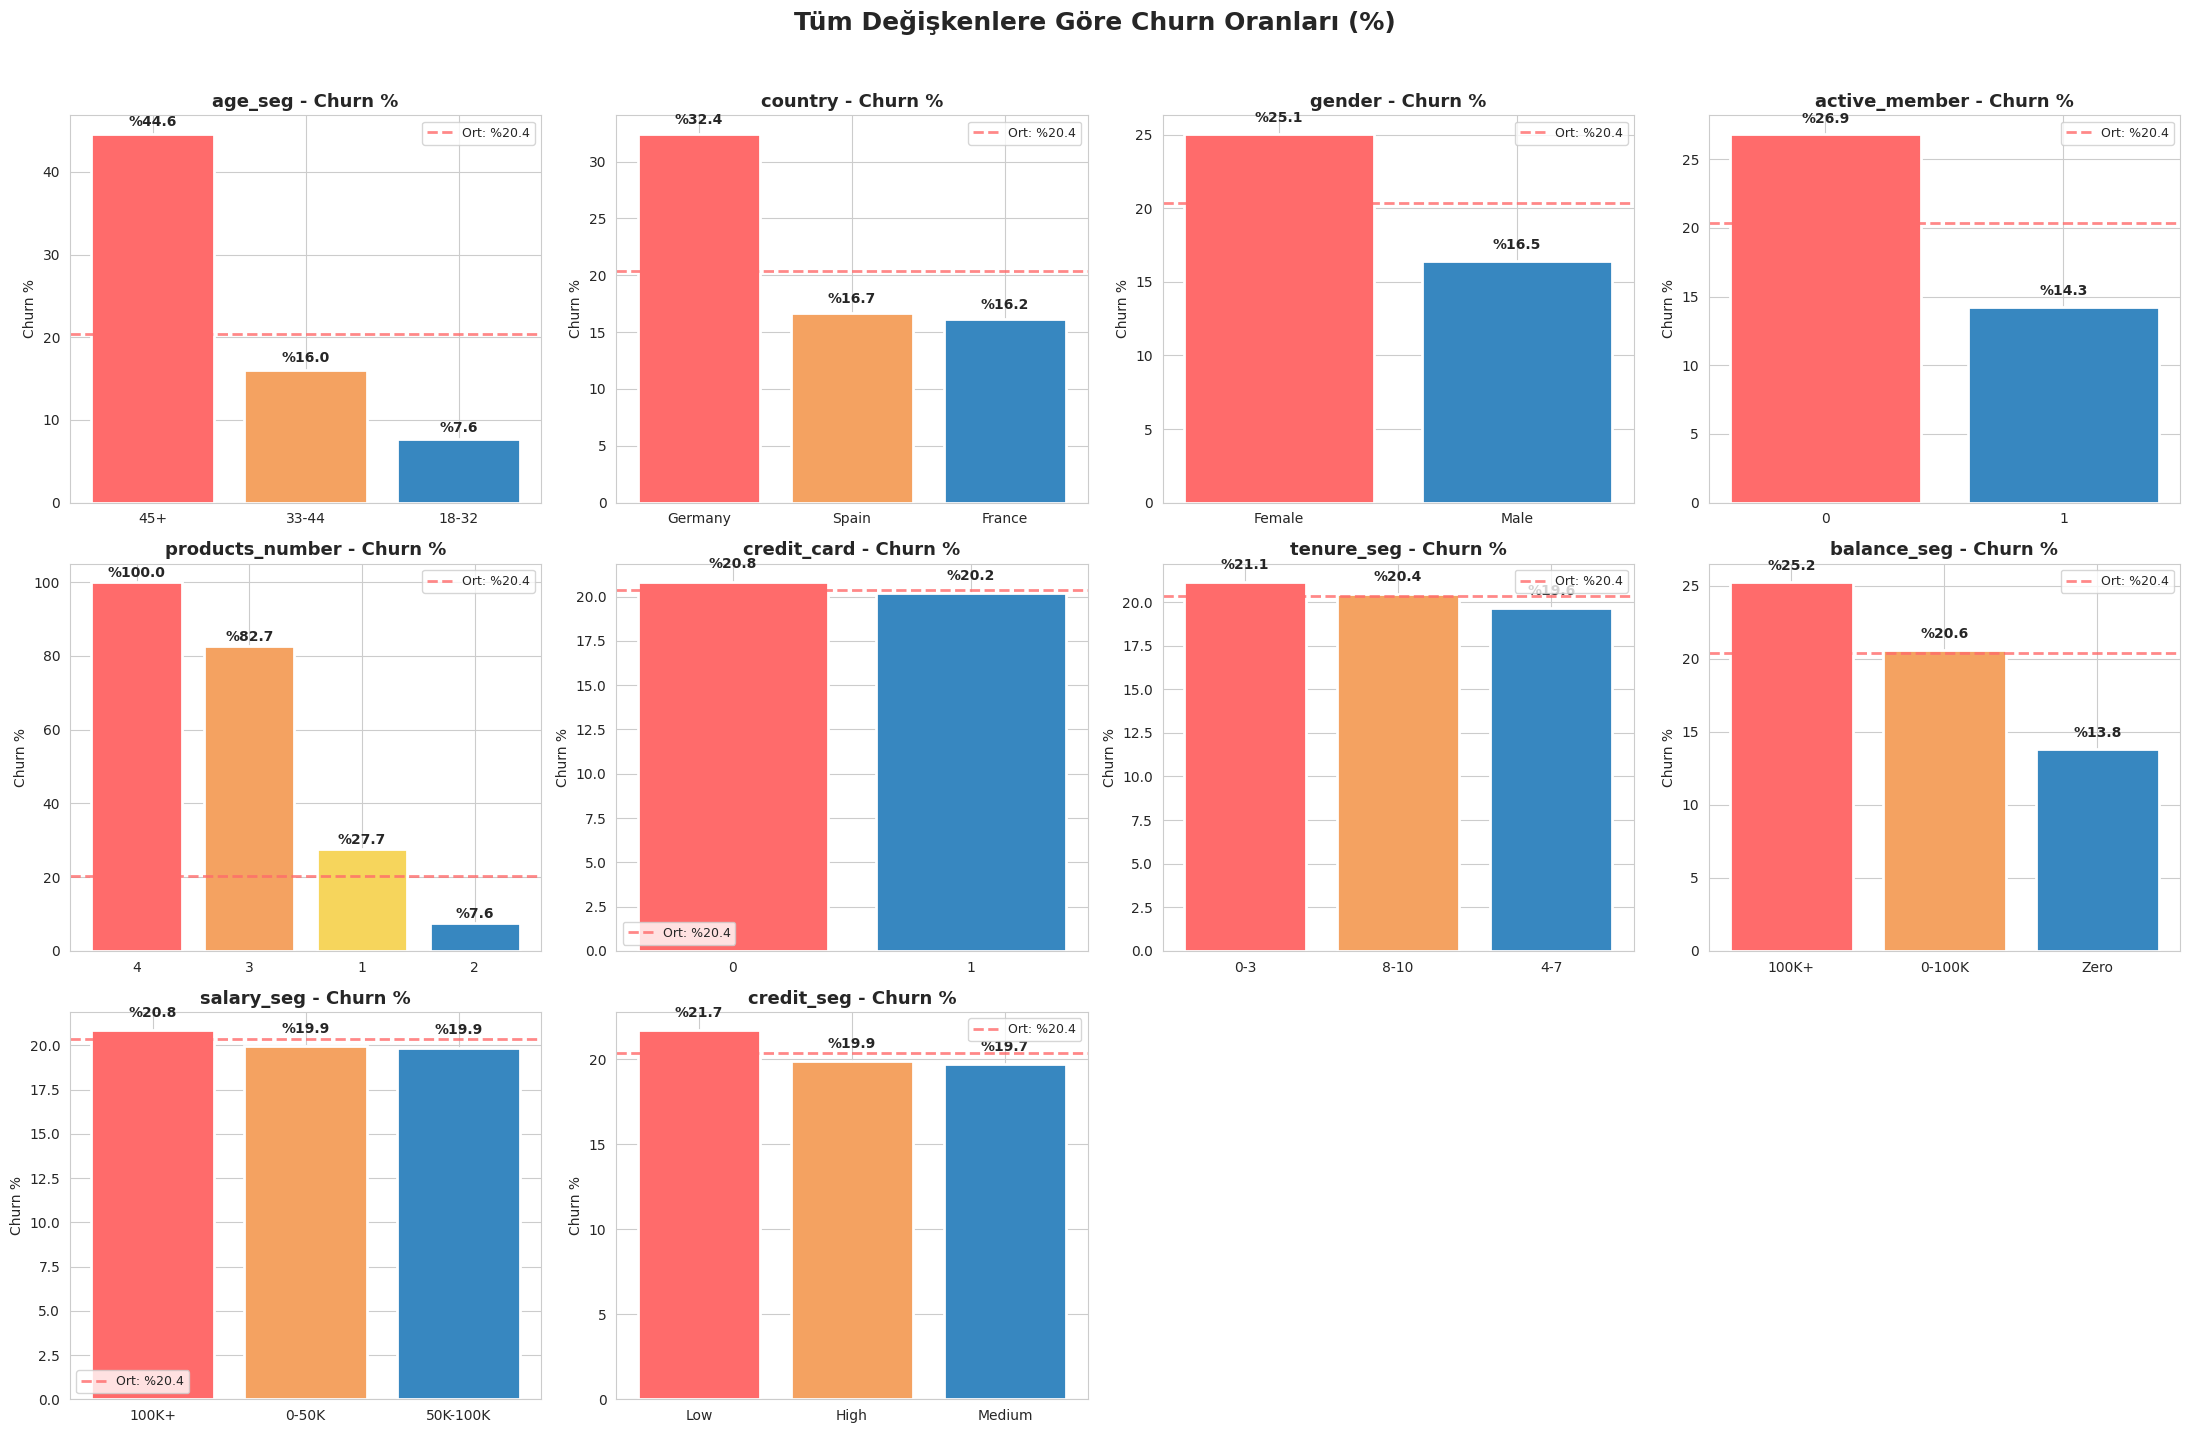

In [18]:

# 1. Segment kolonlarını oluştur

df['age_seg'] = pd.cut(
    df['age'],
    bins=[17, 32, 44, 100],
    labels=['18-32', '33-44', '45+']
)

df['tenure_seg'] = pd.cut(
    df['tenure'],
    bins=[-1, 3, 7, 10],
    labels=['0-3', '4-7', '8-10']
)

df['balance_seg'] = pd.cut(
    df['balance'],
    bins=[-1, 0, 100000, 300000],
    labels=['Zero', '0-100K', '100K+']
)

df['salary_seg'] = pd.cut(
    df['estimated_salary'],
    bins=[0, 50000, 100000, 200000],
    labels=['0-50K', '50K-100K', '100K+']
)

df['credit_seg'] = pd.cut(
    df['credit_score'],
    bins=[349, 600, 700, 850],
    labels=['Low', 'Medium', 'High']
)

# 2. İstenen sıra
all_cols = [
    'age_seg',
    'country',
    'gender',
    'active_member',
    'products_number',
    'credit_card',
    'tenure_seg',
    'balance_seg',
    'salary_seg',
    'credit_seg'
]

# 3. Renkler

high_color = '#ff6b6b'    # kırmızı
mid_color = '#f4a261'     # turuncu
lowmid_color = '#f6d55c'  # sarı
low_color = '#3787c0'     # mavi

overall_churn = df['churn'].mean() * 100


# 4. Grafik alanı

fig, axes = plt.subplots(3, 4, figsize=(22, 14))
axes = axes.flatten()


# 5. Grafikler

for i, col in enumerate(all_cols):

    churn_rate = (
        df.groupby(col, observed=False)['churn']
        .mean()
        .sort_values(ascending=False)
    )

    # products_number için özel renk sırası
    if col == 'products_number':
        color_map = {
            '4': high_color,
            '3': mid_color,
            '1': lowmid_color,
            '2': low_color
        }
        colors = [color_map.get(str(idx), low_color) for idx in churn_rate.index]

    else:
        if len(churn_rate) == 3:
            colors = [high_color, mid_color, low_color]
        elif len(churn_rate) == 2:
            colors = [high_color, low_color]
        elif len(churn_rate) == 4:
            colors = [high_color, mid_color, lowmid_color, low_color]
        else:
            colors = [high_color] * len(churn_rate)

    bars = axes[i].bar(
        churn_rate.index.astype(str),
        churn_rate.values * 100,
        color=colors,
        edgecolor='white',
        linewidth=2
    )

    axes[i].axhline(
        y=overall_churn,
        color='#ff6b6b',
        linestyle='--',
        linewidth=2,
        alpha=0.8,
        label=f'Ort: %{overall_churn:.1f}'
    )

    axes[i].set_title(f'{col} - Churn %', fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Churn %')
    axes[i].legend(fontsize=9)

    for bar, val in zip(bars, churn_rate.values):
        axes[i].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.6,
            f'%{val * 100:.1f}',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )


# 6. Boş eksenleri kapat

for j in range(len(all_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    'Tüm Değişkenlere Göre Churn Oranları (%)',
    fontsize=18,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

Grafikler incelendiğinde churn oranının bazı müşteri gruplarında ortalamanın üzerinde yoğunlaştığı görülmektedir.
Özellikle yaş, ülke, aktif üyelik ve ürün sayısı değişkenlerinde churn oranlarının belirgin şekilde farklılaştığı dikkat çekmektedir.

Bu nedenle sonraki bölümlerde değişkenler demografik, davranışsal ve finansal başlıklar altında daha detaylı analiz edilecektir.


## 6. Demografik KPI Analizi

Bu bölümde müşterilerin ülke, cinsiyet ve yaş gibi demografik özelliklerine göre churn oranları incelenmektedir.

### 6.1 Country vs Churn

In [19]:
country_churn = df.groupby('country')['churn'].agg(
    Musteri_Sayisi='count',
    Churn_Sayisi='sum',
    Churn_Orani='mean'
).round(4)
country_churn['Churn_Orani_%'] = (country_churn['Churn_Orani'] * 100).round(2)
print(country_churn[['Musteri_Sayisi', 'Churn_Sayisi', 'Churn_Orani_%']])

         Musteri_Sayisi  Churn_Sayisi  Churn_Orani_%
country                                             
France             5014           810          16.15
Germany            2509           814          32.44
Spain              2477           413          16.67


- **Almanya:** Churn orani %32.4 ile diger ulkelerin yaklasik 2 kati
- **Fransa:** %16.2
- **Ispanya:** %16.7

Almanya'da musteri kaybi ciddi bir problem.

### 6.2 Gender vs Churn

In [20]:
gender_churn = df.groupby('gender')['churn'].agg(
    Musteri_Sayisi='count',
    Churn_Sayisi='sum',
    Churn_Orani='mean'
).round(4)
gender_churn['Churn_Orani_%'] = (gender_churn['Churn_Orani'] * 100).round(2)
print(gender_churn[['Musteri_Sayisi', 'Churn_Sayisi', 'Churn_Orani_%']])

        Musteri_Sayisi  Churn_Sayisi  Churn_Orani_%
gender                                             
Female            4543          1139          25.07
Male              5457           898          16.46


- **Kadin:** Churn %25.1
- **Erkek:** Churn %16.5

Kadin musteriler erkeklere gore ~1.5 kat daha fazla ayriliyor.

### 6.3 Age vs Churn

In [21]:
# Yas gruplari olustur
def age_segment(age):
    if age <= 32:
        return '18-32 (Young)'
    elif age <= 44:
        return '33-44 (Middle)'
    else:
        return '45+ (Senior)'

df['age_group'] = df['age'].apply(age_segment)

age_churn = df.groupby('age_group')['churn'].agg(
    Musteri_Sayisi='count',
    Churn_Sayisi='sum',
    Churn_Orani='mean'
).round(4)
age_churn['Churn_Orani_%'] = (age_churn['Churn_Orani'] * 100).round(2)
print(age_churn[['Musteri_Sayisi', 'Churn_Sayisi', 'Churn_Orani_%']])

                Musteri_Sayisi  Churn_Sayisi  Churn_Orani_%
age_group                                                  
18-32 (Young)             2790           213           7.63
33-44 (Middle)            4870           780          16.02
45+ (Senior)              2340          1044          44.62


Bu bölümde demografik değişkenler içinden churn açısından en dikkat çekici iki bulgu görsel olarak özetlenmiştir. Grafiklerde yaş grupları ve ülkelere göre churn oranları karşılaştırılmış, en yüksek risk taşıyan kategoriler kırmızı ile vurgulanmıştır.

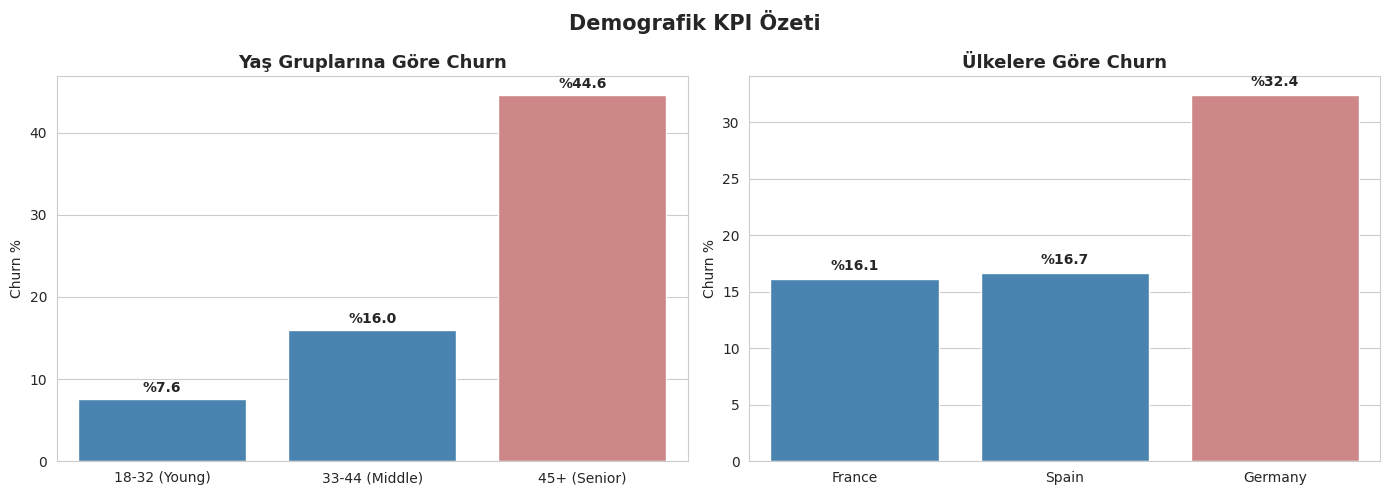

In [22]:
# Demografik KPI özeti: Yaş ve ülkeye göre churn oranları

import matplotlib.pyplot as plt
import seaborn as sns

# Yaş gruplarına göre churn oranları
age_order = ['18-32 (Young)', '33-44 (Middle)', '45+ (Senior)']
age_rates = age_churn.loc[age_order, 'Churn_Orani_%']

age_df = age_rates.reset_index()
age_df.columns = ['Kategori', 'Churn_Orani']
age_df['Renk'] = ['Normal', 'Normal', 'Riskli']

# Ülkelere göre churn oranları
country_order = ['France', 'Spain', 'Germany']
country_rates = country_churn.loc[country_order, 'Churn_Orani_%']

country_df = country_rates.reset_index()
country_df.columns = ['Kategori', 'Churn_Orani']
country_df['Renk'] = ['Normal', 'Normal', 'Riskli']

# Renkler
palette_map = {
    'Normal': main_blue,
    'Riskli': '#d97b7b'
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sol grafik: Yaş
sns.barplot(
    data=age_df,
    x='Kategori',
    y='Churn_Orani',
    hue='Renk',
    dodge=False,
    palette=palette_map,
    legend=False,
    ax=axes[0]
)

axes[0].set_title("Yaş Gruplarına Göre Churn", fontsize=13, fontweight='bold')
axes[0].set_xlabel("")
axes[0].set_ylabel("Churn %")

for i, v in enumerate(age_df['Churn_Orani']):
    axes[0].text(i, v + 0.8, f"%{v:.1f}", ha='center', fontsize=10, fontweight='bold')

# Sağ grafik: Ülke
sns.barplot(
    data=country_df,
    x='Kategori',
    y='Churn_Orani',
    hue='Renk',
    dodge=False,
    palette=palette_map,
    legend=False,
    ax=axes[1]
)

axes[1].set_title("Ülkelere Göre Churn", fontsize=13, fontweight='bold')
axes[1].set_xlabel("")
axes[1].set_ylabel("Churn %")

for i, v in enumerate(country_df['Churn_Orani']):
    axes[1].text(i, v + 0.8, f"%{v:.1f}", ha='center', fontsize=10, fontweight='bold')

plt.suptitle("Demografik KPI Özeti", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Demografik analiz sonuçlarına göre churn oranı yaş grupları arasında belirgin şekilde farklılık göstermektedir. Özellikle 45 yaş ve üzeri müşterilerde churn oranı %44,6 ile oldukça yüksektir. Ülke bazında incelendiğinde ise Germany müşterilerinde churn oranı %32,4 ile diğer ülkelere göre belirgin şekilde daha yüksek görünmektedir. Demografik analiz sonuçlarına göre özellikle yaş ve ülke değişkenlerinin churn oranını etkilediği görülmektedir.


## 7. Davranışsal KPI Analizi

Musterilerin bankayi nasil kullandigina dair degiskenler: aktiflik, urun sayisi, kredi karti, tenure.

### 7.1 Active Member vs Churn

In [23]:
active_churn = df.groupby('active_member')['churn'].agg(
    Musteri_Sayisi='count',
    Churn_Sayisi='sum',
    Churn_Orani='mean'
).round(4)
active_churn.index = ['Pasif (0)', 'Aktif (1)']
active_churn['Churn_Orani_%'] = (active_churn['Churn_Orani'] * 100).round(2)
print(active_churn[['Musteri_Sayisi', 'Churn_Sayisi', 'Churn_Orani_%']])

           Musteri_Sayisi  Churn_Sayisi  Churn_Orani_%
Pasif (0)            4849          1302          26.85
Aktif (1)            5151           735          14.27


- Pasif musteriler: Churn %26.9
- Aktif musteriler: Churn %14.3
- Pasif musteriler aktif musterilere gore yaklaşık 2 kat daha fazla ayriliyor

### 7.2 Products Number vs Churn

In [24]:
products_churn = df.groupby('products_number')['churn'].agg(
    Musteri_Sayisi='count',
    Churn_Sayisi='sum',
    Churn_Orani='mean'
).round(4)
products_churn['Churn_Orani_%'] = (products_churn['Churn_Orani'] * 100).round(2)
print(products_churn[['Musteri_Sayisi', 'Churn_Sayisi', 'Churn_Orani_%']])

                 Musteri_Sayisi  Churn_Sayisi  Churn_Orani_%
products_number                                             
1                          5084          1409          27.71
2                          4590           348           7.58
3                           266           220          82.71
4                            60            60         100.00


- 1 urun: %27.7 churn (5,084 musteri)
- 2 urun: %7.6 churn (4,590 musteri) — en sadik grup
- 3 urun: %82.7 churn (266 musteri)
- 4 urun: %100 churn (60 musteri)

Elde edilen sonuçlara göre, 2 ürünlü müşteriler en sadık segmenttir.Bu segmentte yer alan müşteriler genellikle maaş hesabı ile kredi kartı, maaş hesabı ile kredi gibi bireysel ürün kombinasyonlarının yanı sıra DBS + ticari hesap,POS + ticari hesap,otomatik tahsilat sistemleri + ticari hesap gibi ticari ürünleri birlikte kullanıyor olabilirler. Bu durum, söz konusu müşterilerin bankanın hem finansal hem de operasyonel süreçlerine entegre olduğunu göstermektedir. Banka ile kurulan bu çok yönlü ilişki, müşteri bağlılığını artırarak churn olasılığını azaltmış olabilir.

Buna karşılık, 3–4 ürün kullanan müşterilerde churn oranı çok yüksek görünmektedir. Bu durum, bazı müşterilerde fazla ürün kullanımına bağlı olarak maliyet algısının artması veya ürün yönetiminin karmaşık hale gelmesiyle ilişkili olabilir. Ancak bu gruplardaki müşteri sayısı düşüktür. Bu nedenle yüksek churn sonucu veren bu segment, örneklemin küçüklüğü göz önünde bulundurularak değerlendirilmelidir.

### 7.3 Credit Card vs Churn

In [25]:
cc_churn = df.groupby('credit_card')['churn'].agg(
    Musteri_Sayisi='count',
    Churn_Sayisi='sum',
    Churn_Orani='mean'
).round(4)
cc_churn.index = ['Yok (0)', 'Var (1)']
cc_churn['Churn_Orani_%'] = (cc_churn['Churn_Orani'] * 100).round(2)
print(cc_churn[['Musteri_Sayisi', 'Churn_Sayisi', 'Churn_Orani_%']])

         Musteri_Sayisi  Churn_Sayisi  Churn_Orani_%
Yok (0)            2945           613          20.81
Var (1)            7055          1424          20.18


- Kredi karti olan: %20.2 churn
- Kredi karti olmayan: %20.8 churn
- **Kredi kartı sahipliğinin churn üzerinde anlamlı bir etkisi bulunmamaktadır.**

### 7.4 Tenure vs Churn

In [26]:
def tenure_group(x):
    if x <= 2:
        return '0-2 (New)'
    elif x <= 6:
        return '3-6 (Silver)'
    else:
        return '7-10 (Gold)'

df['tenure_group'] = df['tenure'].apply(tenure_group)

tenure_churn = df.groupby('tenure_group')['churn'].agg(
    Musteri_Sayisi='count',
    Churn_Sayisi='sum',
    Churn_Orani='mean'
).round(4)
tenure_churn['Churn_Orani_%'] = (tenure_churn['Churn_Orani'] * 100).round(2)
print(tenure_churn[['Musteri_Sayisi', 'Churn_Sayisi', 'Churn_Orani_%']])

              Musteri_Sayisi  Churn_Sayisi  Churn_Orani_%
tenure_group                                             
0-2 (New)               2496           528          21.15
3-6 (Silver)            3977           821          20.64
7-10 (Gold)             3527           688          19.51


- New (0-2 yil): %21.2
- Silver (3-6 yil): %20.6
- Gold (7+ yil): %19.5

Tenure arttıkça churn hafif azalıyor ama etki cok zayif.

**Tenure'un churn üzerinde anlamlı bir etkisi bulunmamaktadır.**

Bu bölümde müşterilerin bankayı kullanım davranışlarının churn üzerindeki etkisi incelenmiştir. Özellikle müşterinin aktif olup olmaması ve kullandığı ürün sayısı churn davranışını anlamak açısından önemli göstergeler sunmaktadır. Aşağıdaki grafiklerde bu iki davranışsal değişkenin churn oranları karşılaştırmalı olarak gösterilmektedir.

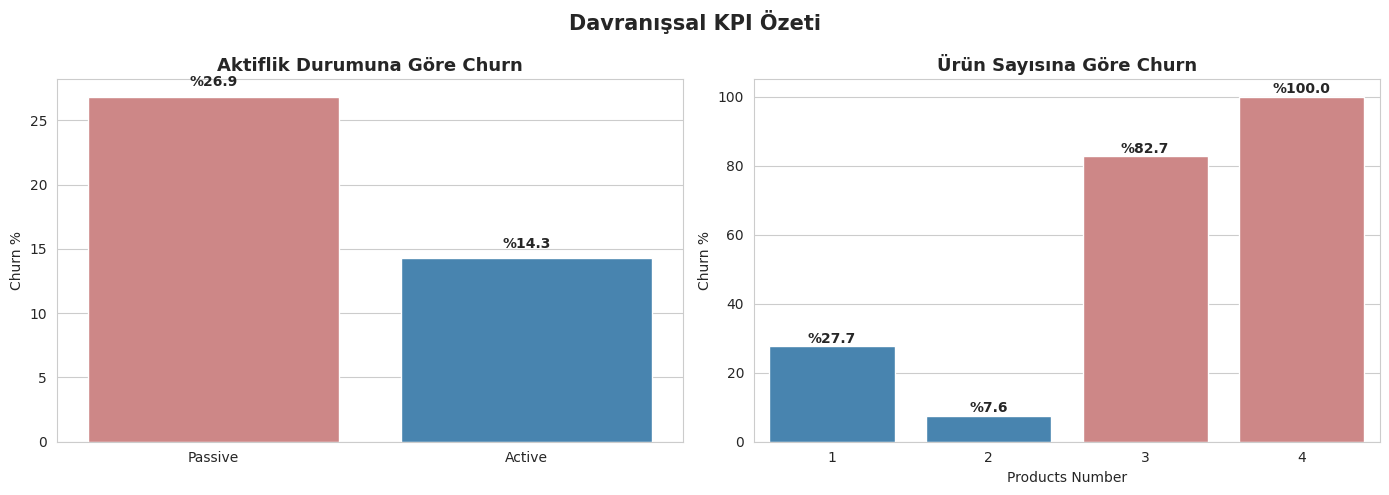

In [27]:
# Davranışsal KPI Özeti: Active Member ve Products Number

import matplotlib.pyplot as plt
import seaborn as sns

# Active member churn oranları
active_rates = df.groupby('active_member')['churn'].mean()*100
active_df = active_rates.reset_index()
active_df.columns = ['Kategori', 'Churn_Orani']
active_df['Kategori'] = active_df['Kategori'].map({0:'Passive', 1:'Active'})
active_df['Renk'] = ['Riskli','Normal']

# Products number churn oranları
product_rates = df.groupby('products_number')['churn'].mean()*100
product_df = product_rates.reset_index()
product_df.columns = ['Kategori','Churn_Orani']

product_df['Renk'] = product_df['Kategori'].apply(
    lambda x: 'Riskli' if x in [3,4] else 'Normal'
)

# renk paleti
palette_map = {
    'Normal': main_blue,
    'Riskli': '#d97b7b'
}

fig, axes = plt.subplots(1,2, figsize=(14,5))

# Active Member grafiği
sns.barplot(
    data=active_df,
    x='Kategori',
    y='Churn_Orani',
    hue='Renk',
    dodge=False,
    palette=palette_map,
    legend=False,
    ax=axes[0]
)

axes[0].set_title("Aktiflik Durumuna Göre Churn", fontsize=13, fontweight='bold')
axes[0].set_xlabel("")
axes[0].set_ylabel("Churn %")

for i,v in enumerate(active_df['Churn_Orani']):
    axes[0].text(i, v+0.8, f"%{v:.1f}", ha='center', fontsize=10, fontweight='bold')


# Products Number grafiği
sns.barplot(
    data=product_df,
    x='Kategori',
    y='Churn_Orani',
    hue='Renk',
    dodge=False,
    palette=palette_map,
    legend=False,
    ax=axes[1]
)

axes[1].set_title("Ürün Sayısına Göre Churn", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Products Number")
axes[1].set_ylabel("Churn %")

for i,v in enumerate(product_df['Churn_Orani']):
    axes[1].text(i, v+1, f"%{v:.1f}", ha='center', fontsize=10, fontweight='bold')


plt.suptitle("Davranışsal KPI Özeti", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Davranışsal analiz sonuçları müşterinin bankayı kullanım şeklinin churn üzerinde önemli bir etkisi olduğunu göstermektedir. Pasif müşterilerde churn oranı %26,9 seviyesine çıkarken aktif müşterilerde bu oran %14,3 seviyesinde kalmaktadır.

Ürün sayısına göre incelendiğinde 2 ürün kullanan müşteriler (4.590 müşteri) %7,6 churn oranı ile en sadık segment olarak görünmektedir. Buna karşılık 3 ürün kullanan 266 müşteride churn %82,7, 4 ürün kullanan 60 müşteride ise %100 olarak hesaplanmıştır. Ancak bu gruplardaki müşteri sayısı oldukça düşük olduğu için bu oranların küçük örneklem etkisiyle yükselmiş olabileceği düşünülmektedir.


## 8. Finansal KPI Analizi

Balance, estimated salary ve credit score degiskenlerinin churn ile iliskisi.

### 8.1 Balance vs Churn

In [28]:
# Bakiye segmentleri
def balance_group(x):
    if x == 0:
        return 'Zero'
    elif x <= 100000:
        return 'Low (0-100K)'
    else:
        return 'High (100K+)'

df['balance_group'] = df['balance'].apply(balance_group)

balance_summary = df.groupby('balance_group')['churn'].agg(
    Musteri_Sayisi='count',
    Churn_Sayisi='sum',
    Churn_Orani='mean'
).round(4)
balance_summary['Churn_Orani_%'] = (balance_summary['Churn_Orani'] * 100).round(2)
print(balance_summary[['Musteri_Sayisi', 'Churn_Sayisi', 'Churn_Orani_%']])

print(f'\nKalan musteri ortalama bakiye: {df[df["churn"]==0]["balance"].mean():,.0f}')
print(f'Ayrilan musteri ortalama bakiye: {df[df["churn"]==1]["balance"].mean():,.0f}')

               Musteri_Sayisi  Churn_Sayisi  Churn_Orani_%
balance_group                                             
High (100K+)             4799          1211          25.23
Low (0-100K)             1584           326          20.58
Zero                     3617           500          13.82

Kalan musteri ortalama bakiye: 72,745
Ayrilan musteri ortalama bakiye: 91,109


- Bakiyesi 0 olan müşterilerde churn oranı %13,8 ile en düşük seviyededir.

- 100K+ bakiyeli müşterilerde churn oranı %25,2 ile en yüksek seviyededir.

- Ayrılan müşterilerin ortalama bakiyesi (91,109), bankada kalan müşterilerin ortalama bakiyesinden (72,745) daha yüksektir.

**Bu durum, bankanın finansal açıdan daha değerli müşterileri kaybetme riski taşıdığını göstermektedir.**

### 8.2 Estimated Salary vs Churn

In [29]:
print(f'Kalan musteri ortalama maas: {df[df["churn"]==0]["estimated_salary"].mean():,.0f}')
print(f'Ayrilan musteri ortalama maas: {df[df["churn"]==1]["estimated_salary"].mean():,.0f}')
print(f'Fark: {abs(df[df["churn"]==0]["estimated_salary"].mean() - df[df["churn"]==1]["estimated_salary"].mean()):,.0f}')

Kalan musteri ortalama maas: 99,738
Ayrilan musteri ortalama maas: 101,466
Fark: 1,727


- Kalan: 99,738 — Ayrilan: 101,466
- Sadece 1,728 fark — 100K'lik maaslarda bu %1.7'lik bir fark
- **Estimated salary'nin churn uzerinde anlamlı bir etkisi bulunmamaktadır.**

### 8.3 Credit Score vs Churn

In [30]:
def credit_segment(x):
    if x <= 600:
        return 'Low (350-600)'
    elif x <= 700:
        return 'Medium (601-700)'
    else:
        return 'High (701-850)'

df['credit_group'] = df['credit_score'].apply(credit_segment)

credit_churn = df.groupby('credit_group')['churn'].agg(
    Musteri_Sayisi='count',
    Churn_Sayisi='sum',
    Churn_Orani='mean'
).round(4)
credit_churn['Churn_Orani_%'] = (credit_churn['Churn_Orani'] * 100).round(2)
print(credit_churn[['Musteri_Sayisi', 'Churn_Sayisi', 'Churn_Orani_%']])

print(f'\nKalan musteri ortalama kredi skoru: {df[df["churn"]==0]["credit_score"].mean():.1f}')
print(f'Ayrilan musteri ortalama kredi skoru: {df[df["churn"]==1]["credit_score"].mean():.1f}')

                  Musteri_Sayisi  Churn_Sayisi  Churn_Orani_%
credit_group                                                 
High (701-850)              3116           619          19.87
Low (350-600)               3066           665          21.69
Medium (601-700)            3818           753          19.72

Kalan musteri ortalama kredi skoru: 651.9
Ayrilan musteri ortalama kredi skoru: 645.4


- Low: %21.7 — Medium: %19.7 — High: %19.9
- Segmentler arasi fark minimal
- **Kredi skorunun churn uzerinde anlamlı bir etkisi bulunmamaktadır.**

Bu bölümde finansal değişkenler içinde churn ile en belirgin ilişki gösteren değişken olan bakiye (balance) görsel olarak özetlenmiştir. Grafik, farklı bakiye gruplarındaki churn oranlarını karşılaştırmakta ve en yüksek risk taşıyan segmenti vurgulamaktadır.

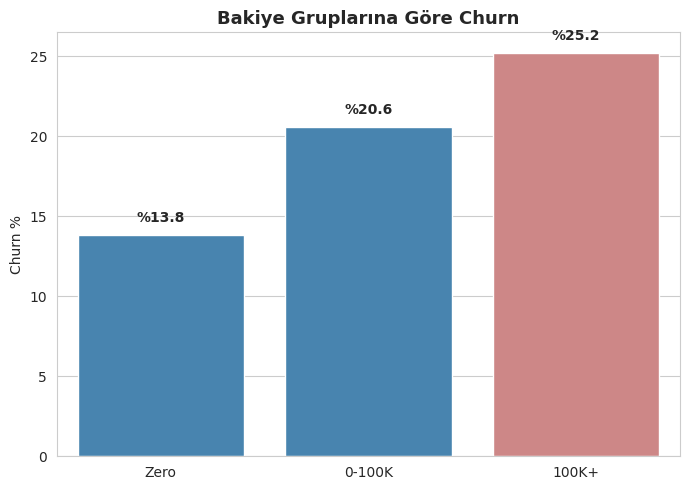

In [31]:
# Finansal KPI Özeti: Balance gruplarına göre churn oranı

import matplotlib.pyplot as plt
import seaborn as sns

# Balance segmentlerini oluştur
df['balance_seg'] = pd.cut(
    df['balance'],
    bins=[-1, 0, 100000, 300000],
    labels=['Zero', '0-100K', '100K+']
)

# Churn oranlarını hesapla
balance_order = ['Zero', '0-100K', '100K+']
balance_rates = df.groupby('balance_seg', observed=False)['churn'].mean() * 100

balance_df = balance_rates.loc[balance_order].reset_index()
balance_df.columns = ['Kategori', 'Churn_Orani']
balance_df['Renk'] = ['Normal', 'Normal', 'Riskli']

# Renk paleti
palette_map = {
    'Normal': main_blue,
    'Riskli': '#d97b7b'
}

# Grafik
plt.figure(figsize=(7, 5))

ax = sns.barplot(
    data=balance_df,
    x='Kategori',
    y='Churn_Orani',
    hue='Renk',
    dodge=False,
    palette=palette_map,
    legend=False
)

ax.set_title("Bakiye Gruplarına Göre Churn", fontsize=13, fontweight='bold')
ax.set_xlabel("")
ax.set_ylabel("Churn %")

for i, v in enumerate(balance_df['Churn_Orani']):
    ax.text(i, v + 0.8, f"%{v:.1f}", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

Grafik incelendiğinde bakiye arttıkça churn oranının da yükseldiği görülmektedir. Özellikle 100K üzeri bakiyeye sahip müşterilerde churn oranı %25 seviyesine çıkmaktadır. Bu durum bankanın finansal açıdan daha değerli müşterileri kaybetme riskinin daha yüksek olabileceğini göstermektedir.
Bu nedenle modelleme aşamasında balance değişkeninin churn tahmini için önemli bir finansal gösterge olabileceği düşünülmektedir.


## 9. Korelasyon Analizi
Bu bölümde değişkenler arasındaki ilişkileri görmek için korelasyon analizi yapılmıştır. Özellikle churn ile diğer değişkenler arasındaki ilişkilere bakılarak churn davranışını daha iyi açıklayabilecek değişkenler belirlenmeye çalışılmıştır. Bu analiz sayesinde modelleme aşamasında hangi değişkenlere daha fazla odaklanılması gerektiği görülmüştür.

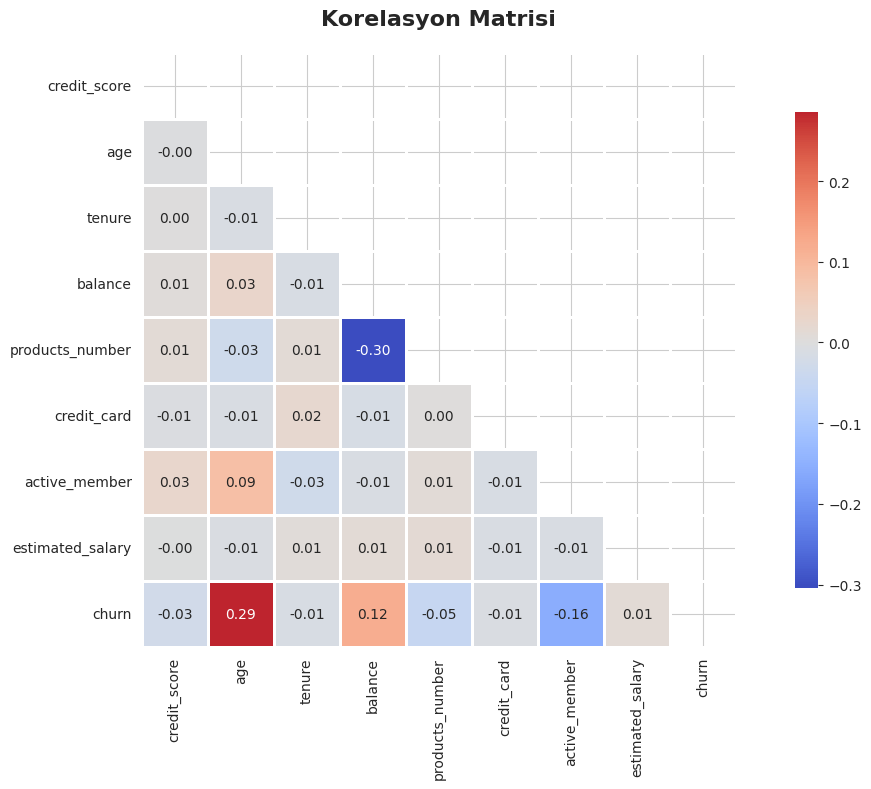


Churn ile Korelasyonlar (mutlak degere gore sirali):
  + age                 : +0.2853
  - active_member       : -0.1561
  + balance             : +0.1185
  - products_number     : -0.0478
  - credit_score        : -0.0271
  - tenure              : -0.0140
  + estimated_salary    : +0.0121
  - credit_card         : -0.0071


In [32]:
corr_cols = ['credit_score', 'age', 'tenure', 'balance', 'products_number',
             'credit_card', 'active_member', 'estimated_salary', 'churn']

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Korelasyon Matrisi', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Churn ile korelasyonlar
print('\nChurn ile Korelasyonlar (mutlak degere gore sirali):')
churn_corr = corr_matrix['churn'].drop('churn').abs().sort_values(ascending=False)
for col, val in churn_corr.items():
    direction = '+' if corr_matrix.loc[col, 'churn'] > 0 else '-'
    print(f'  {direction} {col:20s}: {corr_matrix.loc[col, "churn"]:+.4f}')

- **age (+0.29):** En guclu korelasyon. Yas arttikca churn artiyor.
- **active_member (-0.16):** Aktif musteri daha az ayriliyor.
- **balance (+0.12):** Bakiyesi yuksek olan daha cok ayriliyor.
- **products_number (-0.05):** Korelasyon değeri düşük görünmektedir. Ancak EDA analizinde ürün sayısına göre churn oranlarının değiştiği görülmüştür. Özellikle 2 ürün kullanan müşterilerde churn oranının oldukça düşük olması (%7,6) bu değişken ile churn arasındaki ilişkinin doğrusal olmadığını göstermektedir.
- **credit_score, tenure, estimated_salary, credit_card:** Korelasyon neredeyse sifir — churn uzerinde etkisiz.

**NOT:** **Country değişkeni kategorik olduğu için korelasyon matrisine dahil edilmemiştir. Ancak EDA analizlerinde churn ile anlamlı bir ilişkisi olduğu gözlemlenmiştir.**

## 10. Churn Risk Profili

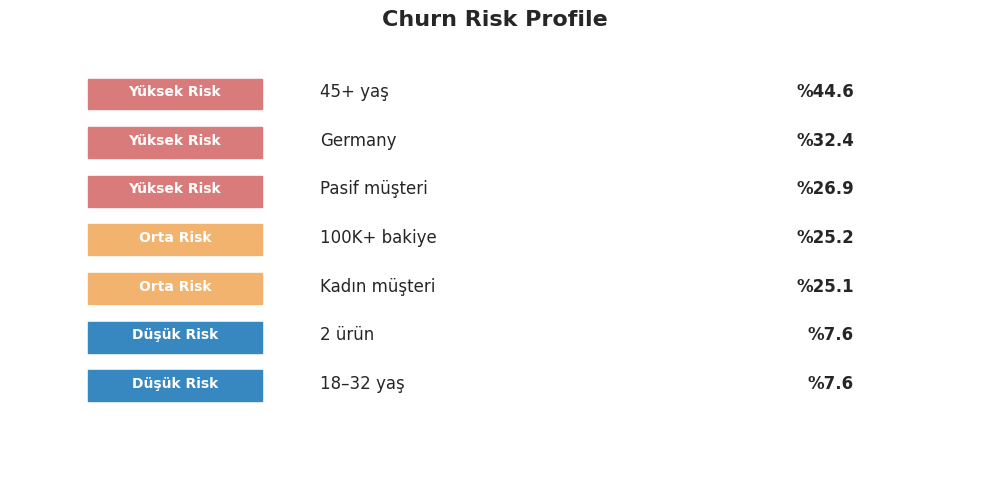

In [33]:
# Churn Risk Profile Görseli

import matplotlib.pyplot as plt

risk_data = [
    ("45+ yaş", "%44.6", "Yüksek Risk"),
    ("Germany", "%32.4", "Yüksek Risk"),
    ("Pasif müşteri", "%26.9", "Yüksek Risk"),
    ("100K+ bakiye", "%25.2", "Orta Risk"),
    ("Kadın müşteri", "%25.1", "Orta Risk"),
    ("2 ürün", "%7.6", "Düşük Risk"),
    ("18–32 yaş", "%7.6", "Düşük Risk"),
]

color_map = {
    "Yüksek Risk": "#d97b7b",   # kırmızımsı
    "Orta Risk": "#f2b36f",     # turuncumsu
    "Düşük Risk": main_blue     # mavi
}

fig, ax = plt.subplots(figsize=(10, 5))
ax.axis("off")

title_x = 0.5
ax.text(title_x, 1.02, "Churn Risk Profile", ha="center", va="bottom",
        fontsize=16, fontweight="bold", transform=ax.transAxes)

start_y = 0.88
step = 0.11

for i, (segment, churn, risk) in enumerate(risk_data):
    y = start_y - i * step

    # Renkli kutu
    ax.add_patch(
        plt.Rectangle((0.08, y - 0.04), 0.18, 0.07, color=color_map[risk], transform=ax.transAxes)
    )

    # Risk etiketi
    ax.text(0.17, y, risk, color="white", ha="center", va="center",
            fontsize=10, fontweight="bold", transform=ax.transAxes)

    # Segment adı
    ax.text(0.32, y, segment, ha="left", va="center",
            fontsize=12, transform=ax.transAxes)

    # Churn oranı
    ax.text(0.87, y, churn, ha="right", va="center",
            fontsize=12, fontweight="bold", transform=ax.transAxes)

plt.tight_layout()
plt.show()

Bu görselde EDA analizlerinde öne çıkan churn riskli müşteri segmentleri özetlenmiştir. Özellikle 45 yaş üzeri müşteriler (%44.6), Germany müşterileri (%32.4) ve pasif müşteriler (%26.9) en yüksek churn riskine sahip gruplar olarak görülmektedir. Buna karşılık 2 ürün kullanan müşteriler ve 18–32 yaş grubu (%7.6) en düşük churn oranına sahip segmentlerdir. Bu sonuçlar, churn davranışının bazı müşteri segmentlerinde belirgin şekilde yoğunlaştığını göstermektedir.

Bu bölümde EDA analizlerinden elde edilen bulgular bir araya getirilerek churn riski yüksek olan tipik müşteri profili oluşturulmuştur. Amaç, churn riskini artıran müşteri özelliklerini tek bir görselde özetlemektir.

## 11. En Riskli Müşteri Profili
Bu bölümde yapılan analizlerden elde edilen bulgular ışığında en riskl, müşteri profili oluşturulmuştur

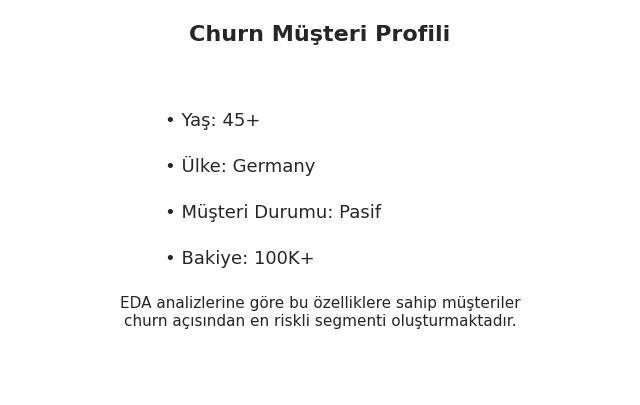

In [34]:

fig, ax = plt.subplots(figsize=(8,5))
ax.axis("off")

# Başlık
ax.text(0.5, 0.92, "Churn Müşteri Profili",
        ha='center', fontsize=16, fontweight='bold')

# Profil kartı
profile_text = [
    "Yaş: 45+",
    "Ülke: Germany",
    "Müşteri Durumu: Pasif",
    "Bakiye: 100K+",
]

y = 0.70
for item in profile_text:
    ax.text(0.25, y, "• " + item, fontsize=13)
    y -= 0.12

# açıklama
ax.text(0.5, 0.18,
        "EDA analizlerine göre bu özelliklere sahip müşteriler\nchurn açısından en riskli segmenti oluşturmaktadır.",
        ha='center', fontsize=11)

plt.show()

EDA analizlerinde elde edilen sonuçlar bir araya getirildiğinde churn riski yüksek olan tipik müşteri profilinin 45 yaş üzeri, Germany’de yaşayan, pasif ve yüksek bakiyeye sahip müşteriler olduğu görülmektedir. Bu segment churn açısından en riskli müşteri grubunu temsil etmektedir.

## 11.1 Modelleme Öncesi Değişkenlerin Değerlendirilmesi

EDA sürecinde churn davranışı ile ilişkili olabilecek değişkenler farklı açılardan incelenmiştir. Bu analizler sonucunda bazı değişkenlerin churn ile daha anlamlı bir ilişki gösterdiği, bazılarının ise model performansına sınırlı katkı sağlayabileceği görülmüştür.

Bu doğrultuda modelleme aşamasına geçmeden önce, churn tahmininde kullanılacak değişkenlerin belirlenmesi ve modele dahil edilecek feature setinin oluşturulması gerekmektedir.


# 12. Feature Seçimi

EDA analizinde elde edilen bulgulara dayanarak modelde kullanılacak değişkenler belirlenmiştir.
Amaç, churn davranışı ile daha güçlü ilişkisi olan değişkenleri modele dahil ederek daha anlamlı bir tahmin modeli oluşturmaktır.

**Modele dahil edilecek feature'lar (guclu etki):**

- age — Korelasyon: +0.285, churn ile en güçlü ilişkiye sahip değişken. Yaş arttıkça churn oranı artmaktadır.

- active_member — Korelasyon: -0.156, pasif müşteriler aktif müşterilere göre yaklaşık 2 kat daha fazla churn etmektedir.

- balance — Korelasyon: +0.119, bakiyesi olan müşterilerde churn oranı daha yüksektir.

- products_number — Korelasyon düşük görünse de EDA analizinde 2 ürün kullanan müşterilerde churn oranının çok düşük olduğu (%7.6) görülmüştür.

- country — Özellikle Germany segmentinde churn oranı %32.4 ile diğer ülkelere göre belirgin şekilde daha yüksektir.

**Modelden cikarilacak degiskenler:**

- customer_id — Sadece müşteri kimliği içerdiği için model açısından anlamlı bir bilgi sağlamaz.

- credit_card — Korelasyon değeri çok düşük (0.007) ve churn davranışı üzerinde belirgin bir etkisi görülmemiştir.

- estimated_salary — Korelasyon 0.012 olup kalan ve ayrılan müşteriler arasında anlamlı bir fark gözlenmemiştir.

- credit_score — Korelasyon 0.027, churn davranışını açıklamada zayıf kalmaktadır.

- tenure — Korelasyon 0.014 ile churn üzerinde belirgin bir etkisi bulunmamaktadır.

- gender- Yapılan analizlerde gender değişkeninde diğer değişkenler kadar dramatik bir fark gözlemlenmemiştir (kadınlarda %25.1, erkeklerde %16.5 churn). Ayrıca sektörel olarak gender değişkeninin churn'ü açıklama gücü zayıf bulunmaktadır. Modelde değişken sayısını azaltmak ve analiz sonuçlarında belirlenen daha etkili değişkenlere odaklanmak amacıyla, modele eklenip eklenmeyeceğine, modelin performansına katkısına bakılarak karar verilecektir.




# 13. Veri Hazırlama ve Modelleme

Bu aşamada churn tahmini için Logistic Regression modeli kullanılacaktır.

Model performansını daha iyi değerlendirebilmek amacıyla iki farklı model kurulmuştur.

  - **Model 1:**
  EDA analizinde churn ile daha güçlü ilişki gösteren temel değişkenler kullanılarak oluşturulmuştur.
Bu modelde yaş, aktiflik durumu, bakiye, ürün sayısı ve ülke değişkenleri yer almaktadır.
Ülke değişkeni One-Hot Encoding ile sayısal forma dönüştürülmüş ve referans kategori bırakılarak modele dahil edilmiştir.

 **NOT:** Gender değişkeni model 1 içinde denenmiş ve modelin performansına katkısı olmadığı için dahil edilmemiştir.

  - **Model 2:**
  Customer_id ve hedef değişken (churn) dışında veri setindeki tüm temel değişkenlerin kullanıldığı modeldir.
EDA sürecinde oluşturulan yaş grubu, bakiye grubu gibi türetilmiş segment değişkenleri modele dahil edilmemiştir.
Amaç, daha fazla değişken kullanmanın model performansını artırıp artırmadığını test etmektir.

Bu iki modelin performansı karşılaştırılarak daha basit ve daha açıklanabilir modelin yeterli olup olmadığı değerlendirilmiştir.

## 13.1 Encoding ve Feature Tanımlama

country ve gender kategorik sutunlardir; lojistik regresyon sayisal girdi bekler. `pd.get_dummies()` ile One-Hot Encoding uyguluyoruz.

In [37]:
# Kategorik değişkenleri sayısal hale getirme
# Logistic Regression sayısal veri ile çalıştığı için country ve gender değişkenlerine One-Hot Encoding uygulanır.
# drop_first=True ile her kategorik değişken için bir referans kategori bırakılır.

df_enc = pd.get_dummies(df, columns=['country', 'gender'], drop_first=True)

# Hedef değişken
TARGET = 'churn'

# Model 1: EDA sonucunda daha güçlü görülen kritik değişkenler
CRITICAL = [
    'age',
    'active_member',
    'balance',
    'products_number',
    'country_Germany',
    'country_Spain'
]

# Model 2: customer_id ve target dışında kalan tüm temel model değişkenleri
# Not: EDA için oluşturulan grup/segment sütunları modele dahil edilmemiştir.
ALL_FEATURES = [
    'credit_score',
    'age',
    'tenure',
    'balance',
    'products_number',
    'credit_card',
    'active_member',
    'estimated_salary',
    'country_Germany',
    'country_Spain',
    'gender_Male'
]

print("Encoding sonrası oluşan sütunlar:")
print(df_enc.columns.tolist())
print()

print(f"Kritik feature sayısı: {len(CRITICAL)}")
print(f"Model 2 toplam feature sayısı: {len(ALL_FEATURES)}")
print()

print("Model 1 feature'ları:")
print(CRITICAL)
print()

print("Model 2 feature'ları:")
print(ALL_FEATURES)

Encoding sonrası oluşan sütunlar:
['customer_id', 'credit_score', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'churn', 'age_seg', 'tenure_seg', 'balance_seg', 'salary_seg', 'credit_seg', 'age_group', 'tenure_group', 'balance_group', 'credit_group', 'country_Germany', 'country_Spain', 'gender_Male']

Kritik feature sayısı: 6
Model 2 toplam feature sayısı: 11

Model 1 feature'ları:
['age', 'active_member', 'balance', 'products_number', 'country_Germany', 'country_Spain']

Model 2 feature'ları:
['credit_score', 'age', 'tenure', 'balance', 'products_number', 'credit_card', 'active_member', 'estimated_salary', 'country_Germany', 'country_Spain', 'gender_Male']


In [38]:
df_enc.columns.tolist()

['customer_id',
 'credit_score',
 'age',
 'tenure',
 'balance',
 'products_number',
 'credit_card',
 'active_member',
 'estimated_salary',
 'churn',
 'age_seg',
 'tenure_seg',
 'balance_seg',
 'salary_seg',
 'credit_seg',
 'age_group',
 'tenure_group',
 'balance_group',
 'credit_group',
 'country_Germany',
 'country_Spain',
 'gender_Male']

## 13.2 Train/Test Bölme

Veri seti %80 eğitim ve %20 test olacak şekilde bölünmüştür.
Bölme işlemi yapılırken eğitim ve test veri setlerinde müşteri kaybı oranının birbirine benzer kalmasına dikkat edilmiştir.
Daha sonra aynı veri bölünmesi kullanılarak iki farklı model için özellik setleri oluşturulmuş ve modellerin performansı adil şekilde karşılaştırılmıştır.

In [39]:
# Hedef değişken
y = df_enc[TARGET]

# Model 1 için kritik değişkenler
X_crit = df_enc[CRITICAL]

# Model 2 için tüm değişkenler
X_all = df_enc[ALL_FEATURES]

# Train-test split
X_crit_train, X_crit_test, y_train, y_test = train_test_split(
    X_crit, y, test_size=0.2, random_state=42, stratify=y
)

X_all_train, X_all_test, _, _ = train_test_split(
    X_all, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Eğitim seti: {len(y_train)} satır")
print(f"Test seti: {len(y_test)} satır")
print(f"Train churn oranı: %{y_train.mean()*100:.1f}")
print(f"Test churn oranı: %{y_test.mean()*100:.1f}")

Eğitim seti: 8000 satır
Test seti: 2000 satır
Train churn oranı: %20.4
Test churn oranı: %20.3


### 13.3 Model Eğitimi

Bu aşamada müşteri kaybını tahmin etmek için Logistic Regression modeli kullanılmıştır.

Model kurulmadan önce değişkenlerin farklı büyüklüklerde olması nedeniyle veriler ölçeklendirilmiştir. Böylece modelin değişkenleri daha dengeli öğrenmesi sağlanmıştır.

Ölçeklendirme işlemi sadece eğitim verisi üzerinde öğrenilmiş ve test verisine aynı dönüşüm uygulanmıştır. Böylece veri sızıntısı (data leakage) riski önlenmiştir.

Veri setinde churn eden müşteri sayısı daha az olduğu için modelde class_weight="balanced" parametresi kullanılmıştır. Bu sayede modelin churn eden müşterileri daha iyi tanıyabilmesi amaçlanmıştır.

Bu aşamada iki farklı model eğitilmiştir:

Model 1: Yapılan analizlerde daha güçlü görülen kritik değişkenler kullanılarak kurulmuştur.

Model 2: Veri setindeki tüm temel değişkenlerin kullanıldığı modeldir.

Bu iki modelin performansı karşılaştırılarak daha basit ve daha açıklanabilir modelin yeterli olup olmadığı değerlendirilmiştir.

In [40]:
# Verilerin ölçeklendirilmesi
scaler_crit = StandardScaler()
scaler_all = StandardScaler()

X_crit_train_scaled = scaler_crit.fit_transform(X_crit_train)
X_crit_test_scaled = scaler_crit.transform(X_crit_test)

X_all_train_scaled = scaler_all.fit_transform(X_all_train)
X_all_test_scaled = scaler_all.transform(X_all_test)

# Model 1: Kritik değişkenler
model_1 = LogisticRegression(class_weight="balanced", random_state=42)

# Model 2: Tüm değişkenler
model_2 = LogisticRegression(class_weight="balanced", random_state=42)

# Model eğitimi
model_1.fit(X_crit_train_scaled, y_train)
model_2.fit(X_all_train_scaled, y_train)

print("Her iki model de eğitildi.")

Her iki model de eğitildi.



# 14. Model Karşılaştırması

Bu aşamada kritik değişkenlerle kurulan Model 1 ile tüm değişkenlerin kullanıldığı Model 2 karşılaştırılmıştır.

Model performansı test verisi üzerinde accuracy, precision, recall ve ROC-AUC metrikleri kullanılarak değerlendirilmiştir. Veri setinde churn eden müşteri oranı düşük olduğu için yalnızca accuracy değerine bakmak yeterli olmayabilir. Bu nedenle churn eden müşterileri yakalama başarısını gösteren recall, modelin churn tahminlerinde ne kadar isabetli olduğunu gösteren precision ve modelin genel ayırt etme gücünü gösteren ROC-AUC değeri birlikte dikkate alınmıştır.

Amaç, daha az değişken kullanılan sade modelin performans açısından yeterli olup olmadığını incelemektir.

## 14.1 Performans Metrikleri Karşılaştırıldı (Model 1 vs Model 2)

In [41]:
# Model 1 tahminleri
y_pred_1 = model_1.predict(X_crit_test_scaled)
y_prob_1 = model_1.predict_proba(X_crit_test_scaled)[:, 1]

# Model 2 tahminleri
y_pred_2 = model_2.predict(X_all_test_scaled)
y_prob_2 = model_2.predict_proba(X_all_test_scaled)[:, 1]

# Model karşılaştırma tablosu
results = pd.DataFrame({
    "Metrik": ["Accuracy", "Precision (Churn)", "Recall (Churn)", "ROC-AUC"],
    "Model 1 - Kritik": [
        round(accuracy_score(y_test, y_pred_1), 4),
        round(precision_score(y_test, y_pred_1), 4),
        round(recall_score(y_test, y_pred_1), 4),
        round(roc_auc_score(y_test, y_prob_1), 4)
    ],
    "Model 2 - Tüm": [
        round(accuracy_score(y_test, y_pred_2), 4),
        round(precision_score(y_test, y_pred_2), 4),
        round(recall_score(y_test, y_pred_2), 4),
        round(roc_auc_score(y_test, y_prob_2), 4)
    ]
})

results


,Metrik,Model 1 - Kritik,Model 2 - Tüm
0,Accuracy,0.7100,0.7135
1,Precision (Churn),0.3860,0.3872
2,Recall (Churn),0.7199,0.7002
3,ROC-AUC,0.7707,0.7771


**Model Karşılaştırma Sonucu**

Model performans sonuçlarına göre her iki modelin de benzer sonuçlar verdiği görülmektedir. Accuracy değerleri birbirine oldukça yakın olup Model 2’de çok küçük bir artış gözlenmiştir. Precision değerleri incelendiğinde de modeller arasında belirgin bir fark bulunmamaktadır.

Churn eden müşterileri yakalama başarısını gösteren recall değeri ise Model 1’de biraz daha yüksek çıkmıştır. Bu durum, EDA analizinde belirlenen kritik değişkenlerle kurulan daha sade modelin churn riskini belirlemede yeterli performans gösterebileceğini düşündürmektedir.

ROC-AUC değerleri incelendiğinde modellerin müşterileri ayırt etme gücünün benzer seviyede olduğu görülmektedir. Bu nedenle model performansını daha detaylı değerlendirebilmek amacıyla bir sonraki adımda ROC eğrileri görsel olarak karşılaştırılmıştır.

### 14.2 ROC Eğrisi (Model 1 vs Model 2)

ROC eğrisi, modellerin churn ve kalacak müşterileri ayırt etme başarısını görsel olarak karşılaştırmak için kullanılmıştır.

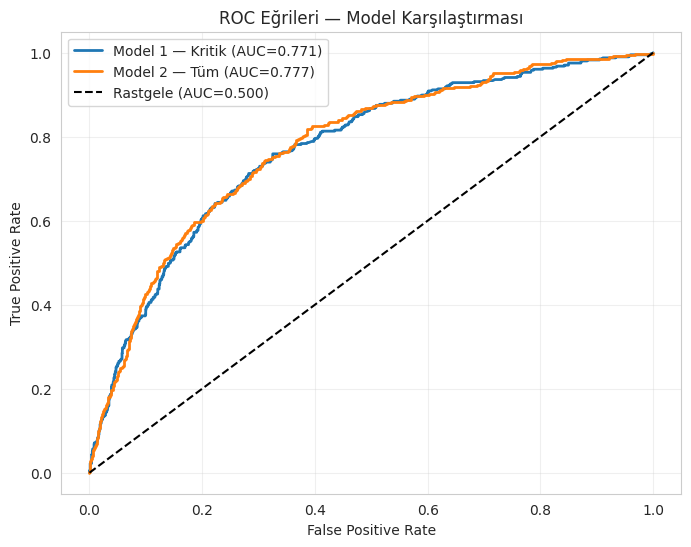

In [42]:
from sklearn.metrics import roc_curve, roc_auc_score

# Model 1 ve Model 2 olasılık tahminleri
y_prob_model1 = model_1.predict_proba(X_crit_test_scaled)[:,1]
y_prob_model2 = model_2.predict_proba(X_all_test_scaled)[:,1]

# ROC değerleri
fpr1, tpr1, _ = roc_curve(y_test, y_prob_model1)
fpr2, tpr2, _ = roc_curve(y_test, y_prob_model2)

auc1 = roc_auc_score(y_test, y_prob_model1)
auc2 = roc_auc_score(y_test, y_prob_model2)

# Grafik
plt.figure(figsize=(8,6))

plt.plot(fpr1, tpr1, label=f"Model 1 — Kritik (AUC={auc1:.3f})", linewidth=2)
plt.plot(fpr2, tpr2, label=f"Model 2 — Tüm (AUC={auc2:.3f})", linewidth=2)

# Rastgele model çizgisi
plt.plot([0,1],[0,1],'k--',label="Rastgele (AUC=0.500)")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Eğrileri — Model Karşılaştırması")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

**ROC Eğrisi Grafik Değerlendirmesi**

Model karşılaştırması sonucunda kritik değişkenlerle kurulan Model 1 ile tüm değişkenlerin kullanıldığı Model 2’nin performanslarının birbirine oldukça yakın olduğu görülmektedir. Test verisi üzerinde hesaplanan accuracy değerleri her iki model için benzer seviyededir. Churn eden müşterileri yakalama başarısını gösteren recall değeri Model 1’de biraz daha yüksek çıkmıştır.

ROC-AUC değerleri incelendiğinde ise modellerin müşterileri ayırt etme gücünün neredeyse aynı olduğu görülmektedir. ROC eğrileri grafik üzerinde karşılaştırıldığında iki modelin eğrilerinin büyük ölçüde üst üste olduğu ve benzer ayırt etme performansı sergilediği anlaşılmaktadır.

Bu sonuçlar, daha fazla değişken kullanılmasının model performansını anlamlı şekilde artırmadığını göstermektedir. Bu nedenle daha az değişken içeren, daha sade ve yorumlanması daha kolay olan **Model 1** tercih edilerek modelleme sürecine bu model üzerinden devam edilmiştir.


# 15. Farklı Eşik Değerleri (Threshold) Denemesi

Lojistik regresyon modeli her müşteri için churn olasılığı üretmektedir. Varsayılan olarak model 0.50 eşik değeri kullanarak sınıflandırma yapar.

Churn problemlerinde müşteriyi kaçırmamak önemli olduğu için eşik değeri düşürüldüğünde model daha fazla churn müşterisini yakalayabilir. Ancak bu durumda yanlış şekilde churn denilen müşteri sayısı da artabilir.

Bu nedenle Model 1 için farklı eşik değerleri test edilmiştir:

0.50 (varsayılan eşik)

0.40

0.35

Amaç, churn müşterilerini yakalama başarısını gösteren recall ile tahminlerin isabetini gösteren precision arasında daha dengeli bir nokta bulmaktır. Bu süreçte accuracy değeri de birlikte değerlendirilmiştir.

In [43]:
# Model 1 olasılık tahminleri
y_prob = model_1.predict_proba(X_crit_test_scaled)[:, 1]

# Threshold tahminleri
y_pred_50 = (y_prob >= 0.50).astype(int)
y_pred_40 = (y_prob >= 0.40).astype(int)
y_pred_35 = (y_prob >= 0.35).astype(int)

# Sonuç tablosu
threshold_results = pd.DataFrame({
    "Metrik": ["Accuracy", "Precision (Churn)", "Recall (Churn)", "ROC-AUC"],

    "Threshold 0.50": [
        round(accuracy_score(y_test, y_pred_50), 4),
        round(precision_score(y_test, y_pred_50), 4),
        round(recall_score(y_test, y_pred_50), 4),
        round(roc_auc_score(y_test, y_prob), 4)
    ],

    "Threshold 0.40": [
        round(accuracy_score(y_test, y_pred_40), 4),
        round(precision_score(y_test, y_pred_40), 4),
        round(recall_score(y_test, y_pred_40), 4),
        round(roc_auc_score(y_test, y_prob), 4)
    ],

    "Threshold 0.35": [
        round(accuracy_score(y_test, y_pred_35), 4),
        round(precision_score(y_test, y_pred_35), 4),
        round(recall_score(y_test, y_pred_35), 4),
        round(roc_auc_score(y_test, y_prob), 4)
    ]
})

threshold_results


,Metrik,Threshold 0.50,Threshold 0.40,Threshold 0.35
0,Accuracy,0.7100,0.5990,0.5380
1,Precision (Churn),0.3860,0.3156,0.2910
2,Recall (Churn),0.7199,0.8305,0.8845
3,ROC-AUC,0.7707,0.7707,0.7707


**Threshold Analizi Sonucu**

Farklı eşik değerleri incelendiğinde eşik değeri düştükçe modelin churn eden müşterileri yakalama başarısının (recall) arttığı görülmektedir. Ancak bu durumda modelin genel doğruluk (accuracy) ve churn tahminlerindeki isabet oranı (precision) azalmaktadır.

Varsayılan eşik değeri olan 0.50’de model daha dengeli bir performans göstermektedir. Eşik değeri 0.40 ve 0.35 seviyelerine düşürüldüğünde model daha fazla churn müşterisini yakalayabilmekte, ancak yanlış churn tahmini sayısı da artmaktadır.

Bu sonuçlar, churn problemlerinde eşik değerinin iş hedeflerine göre ayarlanmasının önemli olduğunu göstermektedir. Müşteriyi kaçırmamak öncelikli ise daha düşük eşik değerleri tercih edilebilir. Ancak gereksiz kampanya maliyetlerini azaltmak için daha dengeli bir eşik değeri seçilmesi daha uygun olabilir.

# 16. Confusion Matrix ile Tahmin Sonuçlarının İncelenmesi

Bu bölümde Model 1 için farklı eşik değerlerinde elde edilen tahmin sonuçları confusion matrix ile incelenmiştir.

Confusion matrix, modelin hangi tahminleri doğru, hangi tahminleri yanlış yaptığını daha net görmek için kullanılır. Böylece yalnızca accuracy veya recall değerine değil, modelin churn ve kalacak müşterileri nasıl sınıflandırdığına da bakılabilir.

Bu bölümde iki farklı eşik değeri karşılaştırılmıştır:

0.50 → varsayılan eşik değeri

0.40 → churn müşterilerini daha fazla yakalamak için düşürülen eşik değeri

Amaç, eşik değiştiğinde modelin doğru ve yanlış tahmin yapısının nasıl değiştiğini daha net görmektir.

## 16.1 Confusion Matrix (Model 1 – Threshold 0.50)

Bu bölümde Model 1’in varsayılan eşik değeri olan 0.50 ile ürettiği tahminler incelenmiştir.
Confusion matrix sayesinde modelin kaç müşteriyi doğru şekilde churn olarak tahmin ettiği, kaç müşteriyi kaçırdığı ve kaç müşteriyi yanlış şekilde churn olarak işaretlediği görülmektedir.

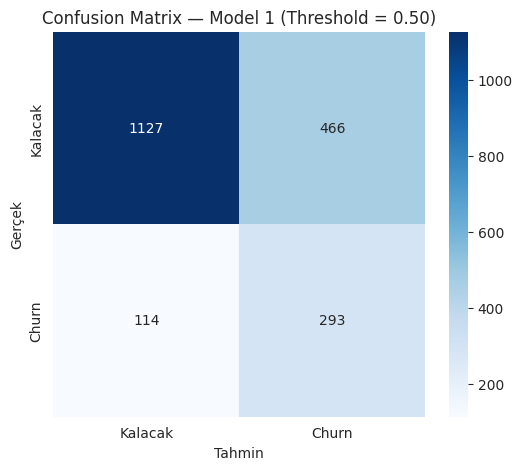

=== Threshold 0.50 Sonuçları ===
True Negative (TN)  - Doğru Kalacak Tahmini : 1127
False Positive (FP) - Yanlış Churn Tahmini  : 466
False Negative (FN) - Kaçırılan Churn       : 114
True Positive (TP)  - Doğru Churn Tahmini   : 293


In [44]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Threshold 0.50 tahminleri
y_pred_50 = (y_prob >= 0.50).astype(int)

# Confusion matrix
cm_50 = confusion_matrix(y_test, y_pred_50)

# Hücre değerlerini ayırma
tn_50, fp_50, fn_50, tp_50 = cm_50.ravel()

# Grafik
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_50,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Kalacak", "Churn"],
    yticklabels=["Kalacak", "Churn"]
)

plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.title("Confusion Matrix — Model 1 (Threshold = 0.50)")
plt.show()

print("=== Threshold 0.50 Sonuçları ===")
print(f"True Negative (TN)  - Doğru Kalacak Tahmini : {tn_50}")
print(f"False Positive (FP) - Yanlış Churn Tahmini  : {fp_50}")
print(f"False Negative (FN) - Kaçırılan Churn       : {fn_50}")
print(f"True Positive (TP)  - Doğru Churn Tahmini   : {tp_50}")

## 16.2 Confusion Matrix (Model 1 – Threshold 0.40)

Bu bölümde aynı model için eşik değeri 0.40 olarak seçilmiş ve tahmin sonuçları yeniden incelenmiştir.
Eşik değeri düşürüldüğünde model daha fazla müşteriyi churn olarak işaretlemektedir. Bu sayede daha fazla churn müşterisi yakalanabilir, ancak yanlış churn tahmini sayısı da artabilir.

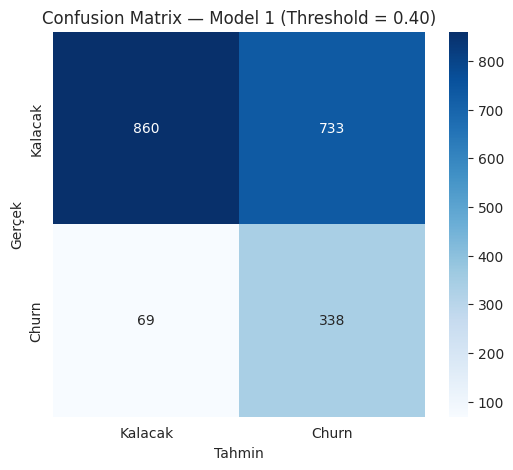

=== Threshold 0.40 Sonuçları ===
True Negative (TN)  - Doğru Kalacak Tahmini : 860
False Positive (FP) - Yanlış Churn Tahmini  : 733
False Negative (FN) - Kaçırılan Churn       : 69
True Positive (TP)  - Doğru Churn Tahmini   : 338


In [45]:
# Threshold 0.40 tahminleri
y_pred_40 = (y_prob >= 0.40).astype(int)

# Confusion matrix
cm_40 = confusion_matrix(y_test, y_pred_40)

# Hücre değerlerini ayırma
tn_40, fp_40, fn_40, tp_40 = cm_40.ravel()

# Grafik
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_40,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Kalacak", "Churn"],
    yticklabels=["Kalacak", "Churn"]
)

plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.title("Confusion Matrix — Model 1 (Threshold = 0.40)")
plt.show()

print("=== Threshold 0.40 Sonuçları ===")
print(f"True Negative (TN)  - Doğru Kalacak Tahmini : {tn_40}")
print(f"False Positive (FP) - Yanlış Churn Tahmini  : {fp_40}")
print(f"False Negative (FN) - Kaçırılan Churn       : {fn_40}")
print(f"True Positive (TP)  - Doğru Churn Tahmini   : {tp_40}")

## 16.3 Tahmin Dağılımı Karşılaştırması

Bu bölümde iki farklı eşik değerinde modelin kaç müşteriyi “kalacak” ve kaç müşteriyi “churn” olarak sınıflandırdığı karşılaştırılmıştır.
Bu karşılaştırma, eşik değeri düştüğünde modelin churn tahmini yapma eğiliminin nasıl değiştiğini göstermektedir.

In [46]:
# Tahmin dağılımları
kalacak_50 = (y_pred_50 == 0).sum()
ayrilacak_50 = (y_pred_50 == 1).sum()

kalacak_40 = (y_pred_40 == 0).sum()
ayrilacak_40 = (y_pred_40 == 1).sum()

print("=== Threshold 0.50 Tahmin Dağılımı ===")
print(f"Kalacak tahmini   : {kalacak_50} ({kalacak_50/len(y_pred_50):.1%})")
print(f"Churn tahmini     : {ayrilacak_50} ({ayrilacak_50/len(y_pred_50):.1%})")

print("\n=== Threshold 0.40 Tahmin Dağılımı ===")
print(f"Kalacak tahmini   : {kalacak_40} ({kalacak_40/len(y_pred_40):.1%})")
print(f"Churn tahmini     : {ayrilacak_40} ({ayrilacak_40/len(y_pred_40):.1%})")

=== Threshold 0.50 Tahmin Dağılımı ===
Kalacak tahmini   : 1241 (62.1%)
Churn tahmini     : 759 (38.0%)

=== Threshold 0.40 Tahmin Dağılımı ===
Kalacak tahmini   : 929 (46.5%)
Churn tahmini     : 1071 (53.5%)



## 16.4 Model Sonuçlarının Karşılaştırılması (Threshold 0.50 vs 0.40)

Model 1 için iki farklı eşik değeri test edilmiştir: varsayılan eşik değeri olan 0.50 ve churn müşterilerini daha fazla yakalayabilmek amacıyla düşürülen 0.40 eşik değeri. Bu karşılaştırmanın amacı, eşik değeri değiştiğinde modelin doğru ve yanlış tahmin yapısının nasıl değiştiğini ve churn müşterilerini yakalama başarısının nasıl etkilendiğini incelemektir.

  - Confusion matrix sonuçlarına göre 0.50 eşik değerinde model, 293 churn müşterisini doğru şekilde tahmin ederken 114 churn müşterisini kaçırmıştır. Ayrıca 1127 müşteriyi doğru şekilde kalacak olarak tahmin etmiş, 466 müşteriyi ise yanlış şekilde churn olarak sınıflandırmıştır. Bu durum modelin genel doğruluk açısından dengeli bir performans gösterdiğini ancak churn müşterilerinin bir kısmını kaçırdığını göstermektedir.

  - Eşik değeri 0.40’a düşürüldüğünde, modelin churn müşterilerini yakalama başarısı belirgin şekilde artmıştır. Doğru churn tahmini sayısı 293’ten 338’e yükselmiş, kaçırılan churn müşteri sayısı ise 114’ten 69’a düşmüştür. Bu sonuç modelin riskli müşterileri daha erken tespit edebildiğini göstermektedir.

Ancak eşik değerinin düşürülmesi modelin daha fazla müşteriyi churn olarak sınıflandırmasına neden olmuş ve yanlış churn tahmini sayısı 466’dan 733’e yükselmiştir. Bu durum modelin genel doğruluk oranını azaltmakla birlikte, churn müşterilerini yakalama performansını güçlendirmektedir.

Churn problemlerinde müşteri kaybını önlemek genellikle gereksiz kampanya maliyetinden daha öenmli olduğu için ve yapılan analizlerde bankanın yüksek bakiyeli müşterileri kaybederek finansal kayıba uğradığı tespit edildiği için, daha fazla churn müşterisini tespit edebilen 0.40 eşik değeri iş hedefleri açısından daha uygun bir denge sunmaktadır.

Bu nedenle daha az değişken kullanan ve yorumlanması daha kolay olan **Model 1, 0.40 eşik değeri** ile nihai model olarak seçilmiştir. Bundan sonraki değerlendirmeler bu model üzerinden yapılacaktır.

# 17. Classification Report

Confusion matrix modelin doğru ve yanlış tahminlerini sayısal olarak göstermektedir. Model performansını daha ayrıntılı değerlendirebilmek için precision, recall ve F1-score gibi metrikleri içeren classification report incelenmiştir.

Precision: Modelin churn dediği müşterilerin ne kadarının gerçekten churn olduğunu gösterir.

Recall: Gerçek churn müşterilerinin ne kadarının model tarafından yakalandığını gösterir.

F1-score: Precision ve recall değerlerinin dengeli bir ortalamasıdır.

Bu metrikler birlikte incelendiğinde modelin churn müşterilerini yakalama başarısı daha net anlaşılabilir.

In [47]:
from sklearn.metrics import classification_report

print("=== Classification Report (Final Model - Threshold 0.40) ===")

print(
    classification_report(
        y_test,
        y_pred_40,
        target_names=["Kalacak", "Churn"]
    )
)

=== Classification Report (Final Model - Threshold 0.40) ===
              precision    recall  f1-score   support

     Kalacak       0.93      0.54      0.68      1593
       Churn       0.32      0.83      0.46       407

    accuracy                           0.60      2000
   macro avg       0.62      0.69      0.57      2000
weighted avg       0.80      0.60      0.64      2000



 **Classification Report Sonuçlarının Değerlendirilmesi**

Classification report sonuçları incelendiğinde nihai modelin churn müşterilerini yakalama konusunda güçlü bir performans sergilediği görülmektedir. Churn sınıfı için recall değeri 0.83 olarak hesaplanmıştır. Bu durum modelin churn eden müşterilerin büyük bir kısmını doğru şekilde tespit edebildiğini göstermektedir.

Churn tahminleri için precision değeri 0.32 olup modelin churn olarak işaretlediği müşterilerin bir kısmının gerçekte bankada kalmaya devam ettiği görülmektedir. Bu durum eşik değerinin düşürülmesiyle modelin daha agresif tahmin yapmasından kaynaklanmaktadır.

Kalacak sınıfı için precision değeri 0.93 olarak hesaplanmıştır. Bu sonuç modelin kalacak olarak tahmin ettiği müşterilerin büyük çoğunluğunda doğru tahmin yaptığını göstermektedir. Ancak kalacak sınıfı için recall değeri 0.54 olup model bazı kalacak müşterileri churn olarak sınıflandırmaktadır.

Modelin genel doğruluk oranı (accuracy) 0.60 olarak hesaplanmıştır. Churn oranının düşük olduğu veri setlerinde accuracy değeri tek başına model performansını değerlendirmek için yeterli olmayabilir. Bu nedenle churn müşterilerini yakalama başarısını gösteren recall metriği daha kritik bir gösterge olarak değerlendirilmiştir.

Genel olarak modelin churn müşterilerini kaçırmamaya odaklanan bir tahmin stratejisi izlediği ve bu yaklaşımın müşteri kaybını önleme açısından iş hedefleriyle uyumlu olduğu görülmektedir.

# 18. Feature Importance (Model Katsayıları)

Lojistik regresyon modeli doğrusal bir model olduğu için her değişken için bir katsayı üretir.
Bu katsayılar, ilgili değişkenin churn tahmini üzerindeki etkisini gösterir.

Pozitif katsayı: Değişken arttıkça churn olasılığı artar

Negatif katsayı: Değişken arttıkça churn olasılığı azalır

Katsayıların mutlak değeri büyüdükçe değişkenin model üzerindeki etkisi artmaktadır.
Bu nedenle değişkenlerin churn davranışı üzerindeki görece önemini incelemek için model katsayıları analiz edilmiştir.

In [48]:
# Model 1 katsayılarını inceleme (Feature Importance)

importance = pd.DataFrame({
    "Feature": X_crit.columns,
    "Coefficient": model_1.coef_[0]
})

# Etki büyüklüğü (mutlak değer)
importance["Impact"] = importance["Coefficient"].abs()

# En etkili değişkenleri üstte görmek için sıralama
importance = importance.sort_values(by="Impact", ascending=False)

importance

,Feature,Coefficient,Impact
0,age,0.801926,0.801926
1,active_member,-0.443245,0.443245
4,country_Germany,0.356275,0.356275
2,balance,0.167537,0.167537
3,products_number,-0.048090,0.048090
5,country_Spain,0.022013,0.022013


## 18.1 Feature Importance Grafiği

Model katsayılarının daha kolay yorumlanabilmesi için değişkenlerin churn üzerindeki etkileri grafik ile görselleştirilmiştir.

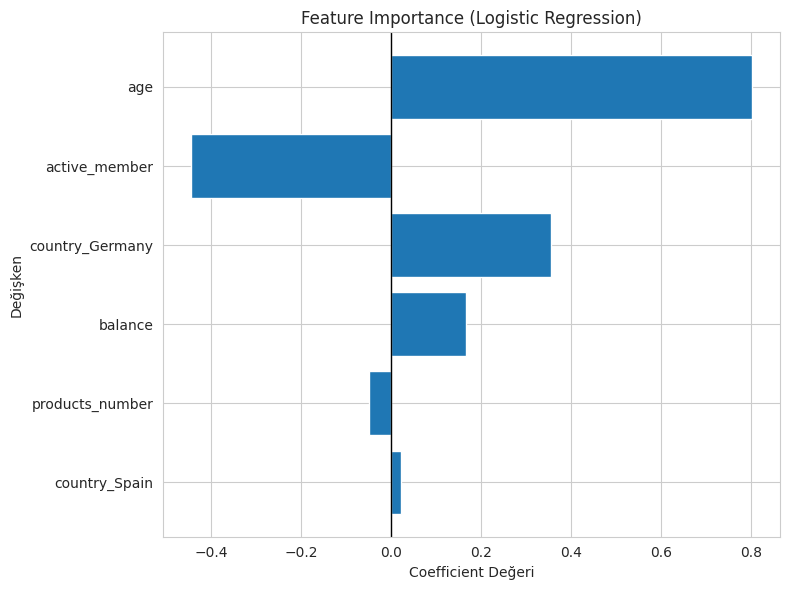

In [49]:
import matplotlib.pyplot as plt
import pandas as pd

# Feature importance dataframe
importance = pd.DataFrame({
    "Feature": CRITICAL,
    "Coefficient": model_1.coef_[0]
})

# Mutlak etki
importance["Impact"] = importance["Coefficient"].abs()

# Etkiye göre sıralama
importance = importance.sort_values(by="Impact", ascending=True)

# Grafik
plt.figure(figsize=(8,6))

plt.barh(
    importance["Feature"],
    importance["Coefficient"]
)

plt.xlabel("Coefficient Değeri")
plt.ylabel("Değişken")
plt.title("Feature Importance (Logistic Regression)")

plt.axvline(x=0, color='black', linewidth=1)

plt.tight_layout()
plt.show()

**Değişken Katsayılarının Değerlendirmesi**

 Model katsayıları incelendiğinde churn tahmini üzerinde en güçlü etkinin **age** değişkenine ait olduğu görülmektedir. Pozitif katsayıya sahip olan bu değişken, yaş arttıkça müşterilerin bankadan ayrılma olasılığının da arttığını göstermektedir.

**active_member** değişkeninin katsayısı negatif yöndedir. Bu durum bankayı aktif kullanan müşterilerin churn riskinin daha düşük olduğunu ve müşteri aktifliğinin müşteri bağlılığı açısından önemli bir faktör olduğunu göstermektedir.

Ülke değişkenlerine bakıldığında **country_Germany** değişkeninin pozitif katsayıya sahip olduğu ve Almanya’daki müşterilerin churn riskinin diğer ülkelere göre daha yüksek olduğu anlaşılmaktadır. Buna karşılık country_Spain değişkeninin katsayısının oldukça düşük olması, bu segmentin model üzerinde sınırlı bir etkiye sahip olduğunu göstermektedir.

**balance** değişkeni pozitif katsayıya sahip olup bakiyesi yüksek müşterilerin churn etme eğiliminin bir miktar daha fazla olduğunu göstermektedir.
**products_number** değişkeninin negatif katsayısı ise ürün sayısı arttıkça churn riskinin hafif şekilde azaldığını işaret etmektedir.

Genel olarak model sonuçları yaş, müşteri aktivitesi ve ülke faktörlerinin churn davranışını açıklamada en belirleyici değişkenler olduğunu ortaya koymaktadır. Bu bulgular veri analizi aşamasında elde edilen gözlemlerle de uyum göstermektedir.


# 19. Risk Segmentasyonu

Makine öğrenmesi modeli her müşteri için churn olasılığı üretmektedir. Bu olasılık değerleri kullanılarak müşteriler risk seviyelerine göre segmentlere ayrılabilir. Bu yaklaşım, bankanın müşteri kaybı riskini daha erken tespit etmesine ve müdahale stratejilerini önceliklendirmesine yardımcı olur.

Bu çalışmada final modelde churn tahmini için kullanılan karar eşiği 0.40 olarak belirlenmiştir. Bu nedenle risk segmentleri model karar mantığı ile uyumlu olacak şekilde aşağıdaki gibi oluşturulmuştur:

High Risk: churn olasılığı ≥ 0.40

Medium Risk: 0.25 ≤ churn olasılığı < 0.40

Low Risk: churn olasılığı < 0.25

Bu segmentasyon sayesinde banka, churn riski yüksek müşterilere öncelikli olarak müdahale edebilir, orta risk grubundaki müşterileri izleyerek bağlılık artırıcı aksiyonlar planlayabilir ve düşük risk grubundaki müşteriler için mevcut müşteri deneyimini korumaya yönelik stratejiler geliştirebilir.

Bu yapı, model çıktılarının operasyonel karar süreçlerinde daha etkin kullanılmasını ve müşteri kaybı yönetiminde kaynakların daha verimli dağıtılmasını sağlar.

In [50]:
# Model 1 için tüm veri üzerinde kritik değişkenleri hazırlama
X_crit_full = df_enc[CRITICAL]

# Model 1 için TRAIN scaler kullanılır (data leakage olmaması için)
scaler_model1 = StandardScaler()
scaler_model1.fit(X_crit_train)

# Tüm veri aynı scaler ile dönüştürülür
X_crit_full_scaled = scaler_model1.transform(X_crit_full)

# Churn olasılıklarını hesaplama
df_seg = df_enc.copy()
df_seg["churn_prob"] = model_1.predict_proba(X_crit_full_scaled)[:, 1]

# ⭐ FINAL MODEL THRESHOLD = 0.40 ile uyumlu segmentasyon
def assign_segment(prob):
    if prob >= 0.40:
        return "High Risk"
    elif prob >= 0.25:
        return "Medium Risk"
    else:
        return "Low Risk"

df_seg["segment"] = df_seg["churn_prob"].apply(assign_segment)

# Segment özet tablosu
seg_stats = df_seg.groupby("segment").agg(
    Musteri_Sayisi=("churn_prob", "count"),
    Gercek_Churn_Orani=("churn", "mean"),
    Ortalama_Churn_Olasiligi=("churn_prob", "mean"),
    Ortalama_Yas=("age", "mean"),
    Aktif_Musteri_Orani=("active_member", "mean"),
    Ortalama_Bakiye=("balance", "mean"),
    Ortalama_Urun_Sayisi=("products_number", "mean"),
    Germany_Orani=("country_Germany", "mean"),
    Spain_Orani=("country_Spain", "mean")
).round(2)

seg_stats

seg_stats

,Musteri_Sayisi,Gercek_Churn_Orani,Ortalama_Churn_Olasiligi,Ortalama_Yas,Aktif_Musteri_Orani,Ortalama_Bakiye,Ortalama_Urun_Sayisi,Germany_Orani,Spain_Orani
segment,,,,,,,,,
High Risk,5250,0.32,0.61,44.63,0.34,93929.56,1.48,0.40,0.21
Low Risk,2148,0.05,0.18,29.93,0.88,44131.19,1.65,0.02,0.31
Medium Risk,2602,0.10,0.32,34.83,0.57,67999.57,1.53,0.13,0.28


**Segment Yorumu**

Model tarafından üretilen churn olasılıklarına göre müşteriler üç risk grubuna ayrılmıştır. Sonuçlar incelendiğinde risk seviyesi arttıkça gerçek churn oranının da belirgin şekilde arttığı görülmektedir. High Risk grubunda churn oranı %32 seviyesine çıkarken, Low Risk grubunda bu oran %5 seviyesinde kalmaktadır. Bu durum modelin müşterileri risk seviyesine göre doğru şekilde sıralayabildiğini göstermektedir.

High Risk grubundaki müşterilerin yaş ortalaması daha yüksek, aktif müşteri oranı ise daha düşüktür. Ayrıca bu müşterilerin ortalama bakiye seviyeleri daha yüksektir ve Almanya oranı diğer segmentlere göre daha fazladır. Bu bulgular, daha yüksek finansal değere sahip ancak bankayla etkileşimi zayıf müşteri profilinde churn riskinin arttığını göstermektedir.

Medium Risk grubu, risk seviyesinin orta düzeyde olduğu ve doğru aksiyonlarla elde tutulabilecek müşterileri temsil etmektedir. Low Risk grubunda ise daha genç, bankayı aktif kullanan ve churn olasılığı düşük müşteriler yoğunlaşmaktadır.

Genel olarak risk segmentasyonu, bankanın müşteri kaybı riskini önceliklendirmesine ve yüksek riskli müşteri gruplarına daha hedefli müdahale stratejileri geliştirmesine yardımcı olmaktadır.

## 19.1 Segment Büyüklüğü ve Churn

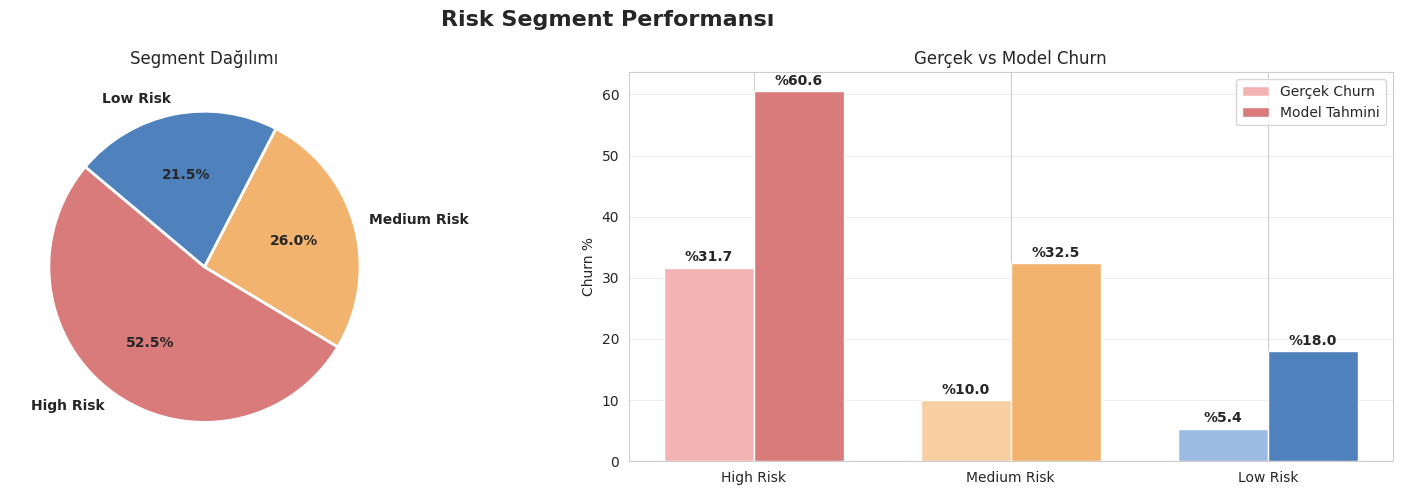

In [51]:

fig, axes = plt.subplots(1, 2, figsize=(16,5))

seg_order = ['High Risk', 'Medium Risk', 'Low Risk']

# Segment ana renkleri
base_colors = {
    'High Risk': '#d97b7b',
    'Medium Risk': '#f2b36f',
    'Low Risk': '#4f81bd'
}

# Gerçek churn için açık tonlar
light_colors = {
    'High Risk': '#f4b3b3',
    'Medium Risk': '#f7cfa3',
    'Low Risk': '#9bbbe3'
}

# Pasta — Segment Dağılımı

counts = df_seg['segment'].value_counts().reindex(seg_order)

axes[0].pie(
    counts.values,
    labels=seg_order,
    colors=[base_colors[s] for s in seg_order],
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    textprops={'fontweight':'bold'}
)

axes[0].set_title('Segment Dağılımı')

# Gerçek vs Model Churn
actual = df_seg.groupby('segment')['churn'].mean().reindex(seg_order)
pred = df_seg.groupby('segment')['churn_prob'].mean().reindex(seg_order)

x = np.arange(len(seg_order))
width = 0.35

bars1 = axes[1].bar(
    x - width/2,
    actual*100,
    width,
    color=[light_colors[s] for s in seg_order],
    label='Gerçek Churn'
)

bars2 = axes[1].bar(
    x + width/2,
    pred*100,
    width,
    color=[base_colors[s] for s in seg_order],
    label='Model Tahmini'
)

axes[1].set_xticks(x)
axes[1].set_xticklabels(seg_order)
axes[1].set_ylabel('Churn %')
axes[1].set_title('Gerçek vs Model Churn')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# Yüzde label — GERÇEK
for bar in bars1:
    height = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'%{height:.1f}',
        ha='center',
        fontweight='bold'
    )

# Yüzde label — MODEL
for bar in bars2:
    height = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'%{height:.1f}',
        ha='center',
        fontweight='bold'
    )

plt.suptitle('Risk Segment Performansı', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

**Risk Segment -Churn Grafik Yorumu**

Bu grafik, müşterilerin risk seviyelerine göre nasıl dağıldığını ve her risk grubunda hem gerçek müşteri kaybı oranını hem de modelin tahmin ettiği kayıp riskini birlikte göstermektedir.

Müşterilerin yarısından fazlası (%52.5) High Risk segmentinde yer almaktadır. Bu grupta gerçek müşteri kaybı oranı %31.7 iken modelin tahmin ettiği risk oranı %60 civarındadır. Bu durum, modelin bu müşterilerde ayrılma ihtimalini daha yüksek gördüğünü ve bankanın bu segmenti öncelikli olarak takip etmesi gerektiğini göstermektedir.

Medium Risk segmentinde müşteri kaybı daha düşük seviyededir. Gerçek churn oranı yaklaşık %10 iken modelin tahmini %32 civarındadır. Bu grup, doğru iletişim ve kampanyalarla kaybedilmeden korunabilecek geçiş segmenti olarak değerlendirilebilir.

Low Risk segmentinde ise hem gerçek churn oranı (%5.4) hem de modelin tahmini (%18) oldukça düşüktür. Bu müşteriler bankaya daha bağlı ve düzenli işlem yapan grubu temsil etmektedir.

Genel olarak grafik, risk seviyesi yükseldikçe müşteri kaybı olasılığının arttığını ve modelin yüksek riskli müşterileri önceden tespit ederek bankaya erken aksiyon alma fırsatı sunduğunu göstermektedir.

# 19.2 Risk Segment Profil Grafikleri

Bu bölümde modelin oluşturduğu risk segmentlerinde yer alan müşterilerin temel özellikleri incelenmiştir.
Segmentlere göre aktiflik oranı, yaş ortalaması, ortalama bakiye ve ülke dağılımı grafiklerle gösterilmiştir.
Amaç, her risk grubunun nasıl bir müşteri profilinden oluştuğunu görmektir

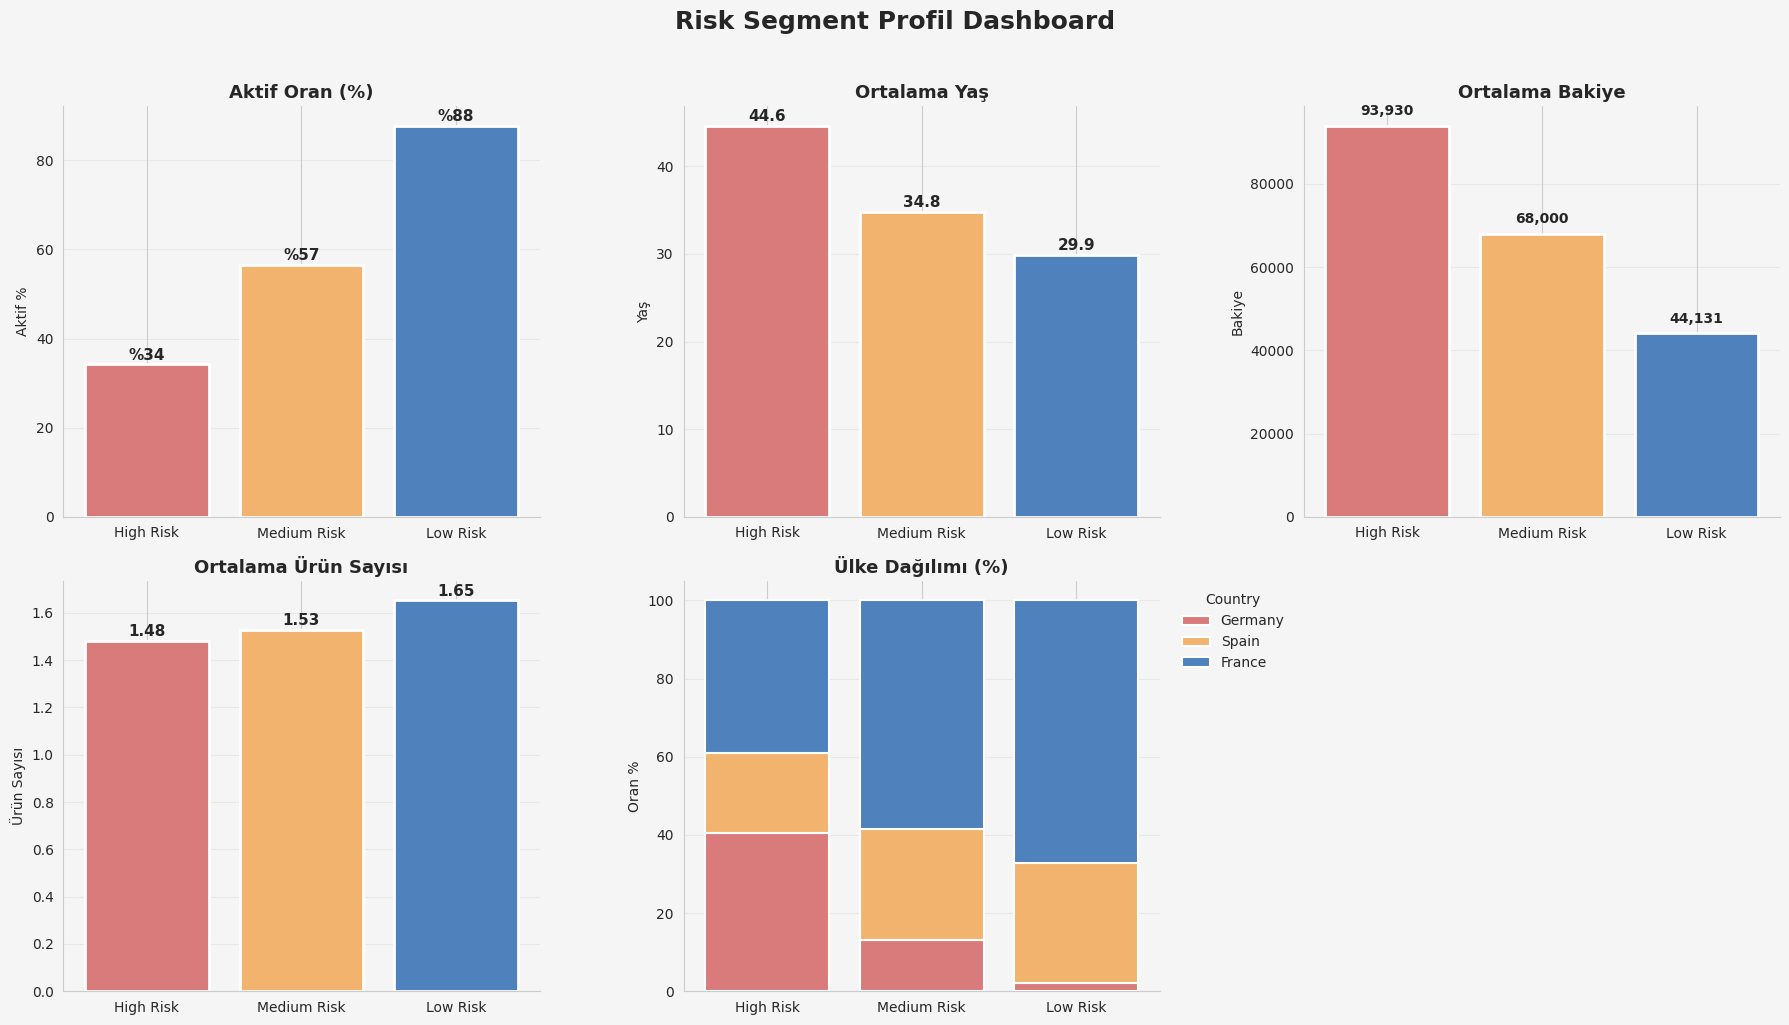

In [52]:
# Segment sırası
seg_order = ['High Risk', 'Medium Risk', 'Low Risk']

# Segment renk paleti
PALETTE = {
    'High Risk': '#d97b7b',
    'Medium Risk': '#f2b36f',
    'Low Risk': '#4f81bd'
}

# Ülke renkleri
country_colors = {
    'Germany': '#d97b7b',
    'Spain': '#f2b36f',
    'France': '#4f81bd'
}

# Grafik için kopya dataframe
df_seg_plot = df_seg.copy()

# France dummy sütununu türet
df_seg_plot['France'] = (
    (df_seg_plot['country_Germany'] == 0) &
    (df_seg_plot['country_Spain'] == 0)
).astype(int)

# 2x3 alan oluşturuyoruz, son kutuyu boş bırakacağız
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor('#f5f5f5')

# 1) Aktif oran
active_by_seg = df_seg_plot.groupby('segment')['active_member'].mean().reindex(seg_order) * 100
bars = axes[0, 0].bar(
    seg_order,
    active_by_seg.values,
    color=[PALETTE[s] for s in seg_order],
    edgecolor='white',
    linewidth=2
)

for bar, val in zip(bars, active_by_seg.values):
    axes[0, 0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f'%{val:.0f}',
        ha='center',
        fontweight='bold',
        fontsize=11
    )

axes[0, 0].set_title('Aktif Oran (%)', fontweight='bold', fontsize=13)
axes[0, 0].set_ylabel('Aktif %')
axes[0, 0].grid(axis='y', alpha=0.3)

# 2) Ortalama yaş
age_by_seg = df_seg_plot.groupby('segment')['age'].mean().reindex(seg_order)
bars = axes[0, 1].bar(
    seg_order,
    age_by_seg.values,
    color=[PALETTE[s] for s in seg_order],
    edgecolor='white',
    linewidth=2
)

for bar, val in zip(bars, age_by_seg.values):
    axes[0, 1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{val:.1f}',
        ha='center',
        fontweight='bold',
        fontsize=11
    )

axes[0, 1].set_title('Ortalama Yaş', fontweight='bold', fontsize=13)
axes[0, 1].set_ylabel('Yaş')
axes[0, 1].grid(axis='y', alpha=0.3)

# 3) Ortalama bakiye
balance_by_seg = df_seg_plot.groupby('segment')['balance'].mean().reindex(seg_order)
bars = axes[0, 2].bar(
    seg_order,
    balance_by_seg.values,
    color=[PALETTE[s] for s in seg_order],
    edgecolor='white',
    linewidth=2
)

for bar, val in zip(bars, balance_by_seg.values):
    axes[0, 2].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2500,
        f'{val:,.0f}',
        ha='center',
        fontweight='bold',
        fontsize=10
    )

axes[0, 2].set_title('Ortalama Bakiye', fontweight='bold', fontsize=13)
axes[0, 2].set_ylabel('Bakiye')
axes[0, 2].grid(axis='y', alpha=0.3)

# 4) Ortalama ürün sayısı
product_by_seg = df_seg_plot.groupby('segment')['products_number'].mean().reindex(seg_order)
bars = axes[1, 0].bar(
    seg_order,
    product_by_seg.values,
    color=[PALETTE[s] for s in seg_order],
    edgecolor='white',
    linewidth=2
)

for bar, val in zip(bars, product_by_seg.values):
    axes[1, 0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f'{val:.2f}',
        ha='center',
        fontweight='bold',
        fontsize=11
    )

axes[1, 0].set_title('Ortalama Ürün Sayısı', fontweight='bold', fontsize=13)
axes[1, 0].set_ylabel('Ürün Sayısı')
axes[1, 0].grid(axis='y', alpha=0.3)

# 5) Ülke dağılımı
country_ratio = df_seg_plot.groupby('segment')[['country_Germany', 'country_Spain', 'France']].mean().reindex(seg_order)
country_ratio = country_ratio.rename(columns={
    'country_Germany': 'Germany',
    'country_Spain': 'Spain'
})

bottom = np.zeros(len(country_ratio))

for country in ['Germany', 'Spain', 'France']:
    axes[1, 1].bar(
        country_ratio.index,
        country_ratio[country].values * 100,
        bottom=bottom * 100,
        label=country,
        color=country_colors[country],
        edgecolor='white',
        linewidth=1.5
    )
    bottom += country_ratio[country].values

axes[1, 1].set_title('Ülke Dağılımı (%)', fontweight='bold', fontsize=13)
axes[1, 1].set_ylabel('Oran %')
axes[1, 1].grid(axis='y', alpha=0.3)

# Legend'ı dışarı taşı
axes[1, 1].legend(
    title='Country',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=False
)

# 6. alanı kapat
axes[1, 2].axis('off')

# Genel başlık
plt.suptitle('Risk Segment Profil Dashboard', fontsize=18, fontweight='bold', y=1.02)

# Görsel düzen
for ax in axes.flat:
    ax.set_facecolor('#f5f5f5')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Grafik Açıklaması**

Risk segmentleri incelendiğinde churn riskinin belirli müşteri profillerinde yoğunlaştığı görülmektedir. High Risk grubundaki müşterilerin daha ileri yaşta, daha az aktif ve daha yüksek bakiyeye sahip olduğu dikkat çekmektedir. Buna karşılık Low Risk grubunda daha genç, bankayı daha aktif kullanan ve churn olasılığı düşük müşteri profili öne çıkmaktadır.

Genel olarak segment profilleri, churn riskinin müşteri davranışı ve demografik özelliklerle birlikte değiştiğini göstermekte ve bankanın risk bazlı müşteri yönetimi stratejileri geliştirmesi için önemli bir içgörü sunmaktadır.

## Veri ile İlgili Dikkat Edilmesi Gereken Noktalar

Proje kapsamında kullanılan veri seti analiz için uygun ve temiz bir yapıdadır. Ancak bazı değişkenlerin neyi tam olarak ifade ettiği net olmadığı için model sonuçları yorumlanırken bu durumun göz önünde bulundurulması önemlidir.

 - active_member değişkeninin hangi kritere göre belirlendiği veri setinde açık şekilde belirtilmemiştir.
Müşterinin son işlem yapması, dijital kanalları kullanması veya maaş hesabı bulunması gibi farklı durumlar aktiflik olarak değerlendirilebilir. Bu nedenle aktiflik ile churn arasındaki güçlü ilişki görülse de bunun arkasındaki nedenler net olarak yorumlanamayabilir.

 - churn değişkeninin tanımı da veri setinde detaylı olarak verilmemiştir.
Müşterinin hesabını kapatması, uzun süre işlem yapmaması ya da bankanın müşteri ile ilişkiyi sonlandırması gibi farklı durumlar churn olarak kabul ediliyor olabilir. Bu durum model sonuçlarının iş tarafında yorumlanmasını kısmen zorlaştırabilir.

 - products_number değişkeninde bazı müşteri gruplarında churn oranının oldukça yüksek görünmesi dikkat çekmektedir.
Özellikle 3 ve üzeri ürün kullanan müşterilerde churn oranının çok yüksek çıkması, bu gruptaki müşteri sayısının düşük olmasından veya veri yapısından kaynaklanıyor olabilir. Bu nedenle bu bulgunun doğrudan karar vermek için tek başına yeterli olmayabileceği değerlendirilmelidir.


# Business Değerlendirme ve Stratejik Öneriler

## İş Problemi

Bu çalışmada bankadaki müşteri kaybı davranışı analiz edilmiş ve churn riski taşıyan müşterileri önceden tahmin edebilecek bir model geliştirilmiştir.

Analiz sürecinde müşteri davranışlarının tüm müşteri kitlesi için benzer olmadığı, bazı segmentlerde churn riskinin belirgin şekilde yoğunlaştığı görülmüştür.

## Elde Edilen Temel İçgörüler

Yapılan analizler, müşteri kaybının belirli müşteri özelliklerinin bir arada bulunduğu segmentlerde daha fazla görüldüğünü göstermektedir.

Özellikle finansal değeri daha yüksek olan ve bankayla etkileşimi görece zayıf kalan müşteri gruplarının churn riski açısından daha hassas olduğu anlaşılmıştır.

**Bu durum bankanın yalnızca müşteri sayısı kaybı değil, aynı zamanda finansal değer kaybı riski ile karşı karşıya olduğunu göstermektedir.**

Model tarafından oluşturulan risk segmentleri de müşteri davranışlarının homojen olmadığını ve bazı müşteri gruplarının bankadan ayrılma ihtimalinin daha yüksek olduğunu ortaya koymuştur.

Bu bulgu, müşteri yönetimi stratejilerinin tüm müşteriler için aynı şekilde uygulanmasının yeterli olmayabileceğini, segment bazlı yaklaşımların daha etkili olabileceğini göstermektedir.

## Stratejik Değerlendirme

Geliştirilen model, bankanın churn riski taşıyan müşteri gruplarını daha erken aşamada fark etmesine yardımcı olabilecek bir araç niteliğindedir.

Bu sayede banka:

- Riskli müşteri segmentlerini önceden belirleyebilir

- Müşteri deneyimini ve iletişim stratejilerini daha hedefli planlayabilir

- Finansal değeri yüksek müşteri gruplarını korumaya yönelik aksiyonlar geliştirebilir

- Pazarlama ve müşteri yönetimi kaynaklarını daha verimli kullanabilir

- Risk segmentasyonu yaklaşımı, müşteri kaybını azaltmaya yönelik proaktif ve veri odaklı karar alma süreçlerini destekleyebilir.

## Öneriler

Churn riski yüksek görünen müşteriler erken dönemde belirlenerek bu müşterilerle daha yakın iletişim kurulabilir. Bu sayede müşterinin bankadan ayrılmadan önce ihtiyaçları anlaşılabilir ve bağlılığı artırmaya yönelik adımlar atılabilir.

Bankada daha yüksek bakiyeye sahip müşteriler için özel kampanyalar, avantajlı ürünler veya kişisel hizmet sunulması bu müşteri grubunun bankada kalma eğilimini güçlendirebilir.

Bankayı daha az kullanan müşterilerin aktifliğini artırmak için dijital kanalların kullanımını teşvik eden uygulamalar, kolaylaştırıcı hizmetler ve işlem bazlı avantajlar sunulabilir.

Müşterilere tek tip yaklaşmak yerine risk seviyelerine göre farklı iletişim ve hizmet stratejileri geliştirilmesi müşteri deneyimini iyileştirebilir ve churn riskini azaltabilir.

Model sonuçlarının düzenli olarak takip edilmesi ve risk gruplarının zaman içinde güncellenmesi, bankanın müşteri kaybını daha erken fark ederek gerekli aksiyonları zamanında almasına yardımcı olabilir.

